<a href="https://colab.research.google.com/github/mavcps123/SC3021---Data-Science-Fundamentals-Final-Group-Project/blob/main/urban_development_crime_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#All relevant imports for the notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import geopandas as gpd
import fiona
import os
import gc
from pyproj import Geod
from shapely.ops import unary_union
from scipy.spatial import cKDTree
from scipy import stats
from matplotlib.patches import Patch

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **“How do urban developmental factors affect the crime rate in a city?”**

## Hypothesis/analysis goal (Ask)





> *Clearly state the data science hypothesis / the analytical goal you pursue in your project. From your description, it should be clear which question you address, what type of analysis is needed, and what quality metric is targeted.*



As the world develops, the number of cities worldwide are increasing rapidly. Safety is an important consideration when evaluating citizens' quality of life, and aside from social policies that are directly related to reducing crime rate such as education, there is also a strong possibility that the structure and design of the city can affect its crime levels. We will thus analyse the possible correlation between the factors of urban development in a city and its crime rate. The factors that we will look into when asssessing the extent of development will be the population density, the intensity of lighting in the city during nighttime as well as the number of surveillance cameras in the city, which serve as both development markers and potential crime deterrents.


## Data source identification and exploration (Prepare)





>*Make a brief requirements analysis for the data and data sources that you require to reach your goal.*





**Requirement analysis.** To address the problem, we require data on city-level crime covering a broad range of crime types. Crime data should be converted into crime rates and aligned with data on key urban development factors, namely surveillance cameras, lighting intensity at night and population density, using consistent geographic identifiers and time periods. This enables meaningful comparison between different cities around the world. It is desirable to have adequate data across diverse cities to ensure sufficient variation in the extent of urban development and crime rates, allowing for accurate analysis.



> *List the sources you will report on for Deliverable 1 and link them to where you found them. In selecting which datasets you want to report on for exploration, take note of the following: (1) The subsequent data preparation and analysis should rely on at least 3 datasets; (2) the discussion concerning exploration needs to feature arguments for why datasets were selected and why others were not.*




**List of considered sources.** In the following, we outline several sources we considered and explored and justify the final source selection (marked with an *), in particular based on concepts discussed in class.

*   **City population density data**
  * [World Cities Database (DS1)*](https://gist.github.com/mchoi2000/e5e0486c74abdbb624db43d7f0783255?#file-worldcities-20210313-population-50000-csv)
  
  * [ List of World Cities by Population Density (DS2)](https://www.kaggle.com/datasets/rajkumarpandey02/list-of-world-cities-by-population-density)

  * [ Countries by Continent (DS6)](https://www.kaggle.com/datasets/hserdaraltan/countries-by-continent)

  * [ Land Cover Data(DS7)*](https://www.kaggle.com/datasets/thedevastator/global-urban-area-indicators?resource=download)


*   **Lighting data**
  * [ Globe at Night - Sky Brightness Monitoring Network (DS3)*](https://globeatnight.org/maps-data/)

*   **Surveillance camera data**
  * [ Cities with CCTV & Crime Index (DS4)*](https://www.kaggle.com/code/kkhandekar/cities-with-cctv-crime-index-an-analysis/input)

*   **Crime rate data**
  * [ World Crime Index (DS5)*](https://www.kaggle.com/datasets/arsalanrehman/world-crime-index-2023?resource=download)


>*For further processing, the data first needs to be loaded. As sample_data is flushed regularly, you may mount a personal Google Drive to read data from there while working on your project. However, your deliverables must include code to read in data from the temporary sample_data folder, where we will upload the data referenced above for evaluation. Therefore, make sure the provided link / information refers to a specific file.*

### Guideline: Dataset exploration discussion



> We acknowledge that each dataset requires different exploration steps to come to the conclusion whether or not to use it. Therefore, no detailed guideline can be given, but we recommend incorporating the following sections:
*   Brief description of downloaded data and reflection on how well it matches requirements or how it is amenable to match the requirements.
*   Profiling steps that should include a short description, the code to execute these, and an interpretation and critical discussion of the results with respect to the suitability of the dataset for addressing the analytical task.
* Discussion of the quality of the data relating to aspects to be considered during data preparation and analysis. It should refer to at least two different quality criteria per explored dataset, one beign assessed positively and one assessed as problematic.
* Concluding paragraph that summarizes (non-)suitability and important points to take note of if the dataset is selected to be used.  






### DS1: World Cities database exploration

**Description**. The Github dataset, downloaded on 2/3/2026, contains the city name, the city's geographical latitude and longitude coordinates, the country the city is in as well as its population, offering relevant information for our analysis. The inclusion of city name and country is at an appropriate granularity for our analysis and gives us potential keys to use to combine the population data with crime rate or urban development data for each country. Furthermore, the inclusion of latitudinal and longitudinal coordinates can also provide us with another way to combine datasets, especially when considering datasets such as DS3. This is because DS3 measures the brightness of the city at night, so being able to reference exact coordinates would ensure a better match, since different parts of the city can be lit up to different extents.

Required info | Your answer
-------------------|------------------
GenAI tool name | Claude AI
Input prompt | Generate a python function called safe_to_numeric that optimises memory usage
Generated output |see code cell in DS1 - code cell 1
Impacted notebook cell | DS1 - code cell 1

In [2]:
#prompt: Generate a python function called safe_to_numeric that optimises memory usage
def safe_to_numeric(col):
    try:
        return pd.to_numeric(col, downcast='float')
    except:
        return col

  This converts each column in a dataset to a numeric (float) type. If a column can be converted, it is converted and downcasted to the smallest float type to save memory. If a column can't be converted, it silently catches the error and returns the unchanged column.                                  
  This is applied via df.apply which runs it on every column in the DataFrame. This ensures numeric columns are stored as proper numbers rather than strings without crashing on text columns, which can happen when pandas reads CSVs and misidentifies the type.

The code below imports the data into a DataFrame and displays the first few rows, so as to show the data that is stored in the dataset.

In [3]:
# Get table data from the csv file about world city populations, using the file mounted in Google Drive

# Read in the csv file into a DataFrame
df1 = pd.read_csv('/content/drive/MyDrive/SC3021/DS1 World Cities Database.csv')
df1 = df1.apply(safe_to_numeric)


# Print the first 10 rows of the DataFrame to verify it loaded correctly
print(df1.head(10))

          city        lat         lng       country  population
0        Tokyo  35.689701  139.692200         Japan  37977000.0
1      Jakarta  -6.214600  106.845100     Indonesia  34540000.0
2        Delhi  28.660000   77.230003         India  29617000.0
3       Mumbai  18.966700   72.833298         India  23355000.0
4       Manila  14.595800  120.977203   Philippines  23088000.0
5     Shanghai  31.166700  121.466698         China  22120000.0
6    São Paulo -23.550400  -46.633900        Brazil  22046000.0
7        Seoul  37.583302  127.000000  Korea, South  21794000.0
8  Mexico City  19.433300  -99.133301        Mexico  20996000.0
9    Guangzhou  23.128799  113.259003         China  20902000.0


From the data displayed above, we can see that the latitude and longitude is stored in the Decimal Degree format. This has to be taken into account when combining with other datasets, as the latitudinal and longitudinal coordinates can also be stored in the Degrees, Minutes, Seconds or the Degrees, Decimal Minutes formats, both of which are common unit formats for latitude and longitude. It also seems that a wide variety of cities across the world are included in the dataset, which allows for a sufficient geographical spread of data. A more detailed analysis is required to see if the datapoints are mostly concentrated in one region or are sufficiently varied across space.

**Exploring the geographical variety of the cities included in the dataset**

In [4]:
# Get the metadata on number of unique countries represented
print("Total number of unique countries: ", df1["country"].nunique(), "\n")

# Get the metadata on number of unique countries represented
print("Total number of unique cities: ", df1["city"].nunique(), "\n")

Total number of unique countries:  189 

Total number of unique cities:  6901 



We see that there are 189 countries represented, which seems like a good spread of data. However, we must also consider the geographical region in which these countries are situated. To check for this, we will make use of another dataset, DS6, to map each country in DS1 to its corresponding continent. To do this, we will make use of a left outer join.

In [5]:
# Read the CSV file into a DataFrame
continents = pd.read_csv("/content/drive/MyDrive/SC3021/DS6 Countries by continents.csv")
print(continents.head())

  Continent   Country
0    Africa   Algeria
1    Africa    Angola
2    Africa     Benin
3    Africa  Botswana
4    Africa   Burkina


We can see that the attribute for country is named differently in DS6 ("Country") compared to DS1 ("country"), so we will rename it and then perform the left outer join.

In [6]:
# Renaming the "Country" attribute in DS6 to "country"
continents = continents.rename(columns ={"Country" : "country"})

# Performing left outer join
df = df1.merge(continents, on="country", how= "left")

# Printing the value counts of each continent
print(df["Continent"].value_counts())

Continent
Asia             2665
North America    1518
Europe           1359
South America     698
Africa            619
Oceania            51
Name: count, dtype: int64


From above, the value distribution for the continents covered by the dataset is varied and substantial, providing data points for more than 600 countries for each continent with the exception of Oceania. Since Oceania is the smallest continent in the world by a significant margin, having data points for only 51 countries in Oceania is acceptable, but we can see if other datasets have more data on Oceania to enrich this dataset.

**Data quality considerations**

We highlight the following quality criteria that we assessed (among others) to determine the suitability of the dataset for our task:


*   In terms of completeness, the dataset satisfies our requirement for the task at hand as it is quite comprehensive in the coverage of population data worldwide, and it also has the appropriate level of granularity (i.e. data at the city and country level)
*   The data was last updated on 11 May 2025, and this relevancy should be taken into consideration when we use this dataset in conjunction with the other datasets, which may have had their data sourced during different time periods. A significant mismatch in the time of data collection could cause inaccuracy in analysis.
* Although the data was sourced from Github, further inspection revealed that the owner of the Github dataset originally obtained the data from the World Cities Database by Simplemaps, which sourced for data from authoritative sources such as the NGIA, US Geological Survey, US Census Bureau, and NASA, thus making it a reputable data source.

Overall, this dataset provides a reputable, rather up-to-date and good spread of population data across the different geographical regions, allowing us to do a comprehensive analysis across multiple countries and continents. This will prevent skewed results, since crime rate can also depend on a multitude of other factors, and having a good geographical spread of data can help minimise the effect of other factors on our results.


**Conclusion for World Cities Database dataset**

In light of the above data exploration, we consider the dataset suited for our analysis with the following caveats, which we will keep in mind during data preparation and analysis:

*   Although the dataset covers a wide range of geographical regions, we will require complementary datasets in order to derive population density, which is the main factor that we are choosing to consider. Therefore, the need to combine datasets may result in heterogeneities that have to be resolved.

* There is significantly less data from the Oceanic region, which may result in our final model coming to a less accurate conclusion when considering cities from that region.




### DS2: List of World Cities by Population Density

**Description.** We downloaded the CSV file from Kaggle on 2/3/2026. We first load the data into a dataframe so that we can get an idea of the stored data. We notice that the dataset contains attributes on the cities' names, populations, area, population density and country that the city belongs to. The data is at an appropriate granularity for our analysis since all the attributes are at the city level. Furthermore, it already provides population density within the dataset itself (unlike DS1), so we do not have to derive it by consulting additional datasets.

In [7]:
# Read the CSV file into a DataFrame
df_density = pd.read_csv("/content/drive/MyDrive/SC3021/DS2 List of world cities by population density.csv")
df_density = df_density.apply(safe_to_numeric)

# Print the first 5 rows of the DataFrame to display the data
print(df_density.head(5))


   Unnamed: 0       City    Population Area (km²) Area (mi²)  Density (/km²)  \
0         0.0       Malé    153,904[1]   1.956[1]      0.755         78683.0   
1         1.0     Manila  1,660,714[2]   38.55[3]      14.88         43079.0   
2         2.0      Bogor    866,034[4]   21.56[5]       8.32         40169.0   
3         3.0   Titagarh    124,213[6]    3.24[7]       1.25         38337.0   
4         4.0  Baranagar    250,768[6]    7.12[7]       2.75         35220.0   

   Density (/mi²)      Country  
0        203846.0     Maldives  
1        111576.0  Philippines  
2        104037.0    Indonesia  
3         99293.0        India  
4         91220.0        India  


**Profiling geographic coverage**

We perform some data profiling on the data to get a better idea of the geographic regions that it spans, so that we can see if it is varied enough for our intended analysis.

In [8]:
# Print the total number of unique values for each attribute
print(df_density.nunique())


Unnamed: 0        50
City              50
Population        50
Area (km²)        50
Area (mi²)        49
Density (/km²)    49
Density (/mi²)    49
Country           14
dtype: int64


Upon further analysis of the metadata, we see that the geographical coverage of the data is even more limited than it first appeared to be. The data only ranges across 14 different countries even though there are 50 cities included, so this dataset alone is unable to provide comprehensive coverage for analysis. We could still use this dataset to supplement DS1 to provide us with data on population density that is more comprehensive and geographically varied, but since DS1 already covers a wide range of regions and is a reputable source of data, we decided not to use this dataset.

**Quality considerations**

We summarize key quality aspects as follows:


*   For our task, the data is not sufficiently complete, because it does not cover a wide range of geographical regions
*   The documentation of the dataset on Kaggle reveals that the data was web-scraped from Wikipedia. Since the population data on Wikipedia was sourced from multiple sources and retrieved at different times, the relevancy of the data varies for each row and is not cohesive



**Conclusion for the List of World Cities by Population Density dataset**

On its own, the List of World Cities by Population Density dataset is too small and too temporally inconsistent to be used in our analysis.

### DS3: Globe at Night - Sky Brightness Monitoring Network

**Description.** We downloaded the CSV file from the Globe at Night website on 2/3/2026. It contains 17 attributes, but only some of those attributes are relevant to our analysis. Thus, we will remove the irrelevant attributes and only retain the columns that are required for our analysis, as our aim is to merge this dataset with DS1 to obtain a column for "city".

In [9]:
# Read the CSV file into a DataFrame
df_brightness = pd.read_csv('/content/drive/MyDrive/SC3021/DS3 Globe at Night - Sky Brightness Monitoring Network.csv')
df_brightness = df_brightness.apply(safe_to_numeric)

# Print the first 5 rows of the DataFrame to verify it loaded correctly
print(df_brightness.head())
print(df_brightness.tail())

         ID ObsType   Latitude  Longitude  Elevation(m)   LocalDate LocalTime  \
0  335973.0     GAN  45.494347  15.533149    110.849998  2024-07-27     22:33   
1  335972.0     GAN  45.499866  15.525713    111.139999  2024-07-27     22:25   
2  335971.0     GAN  45.486893  15.538268    113.339996  2024-07-27     22:24   
3  335970.0     GAN  45.513187  15.521187    114.900002  2024-07-27     22:20   
4  335939.0     GAN  45.495689  15.467396    153.389999  2024-07-27     22:31   

       UTDate UTTime  LimitingMag  SQMReading  SQMSerial CloudCover  \
0  2024-07-27  20:33          2.0         NaN        NaN      clear   
1  2024-07-27  20:25          2.0         NaN        NaN      clear   
2  2024-07-27  20:24          2.0         NaN        NaN      clear   
3  2024-07-27  20:20          3.0         NaN        NaN      clear   
4  2024-07-27  20:31          6.0         NaN        NaN      clear   

  Constellation SkyComment                              LocationComment  \
0      Herc

In [10]:
# Removing columns so that the DataFrame only retains relevant attributes
df_brightness = df_brightness[["Latitude", "Longitude", "Country", "LimitingMag"]]
# Printing the last 5 rows of the DataFrame to check
print(df_brightness.head())
print(df_brightness.tail())

    Latitude  Longitude  Country  LimitingMag
0  45.494347  15.533149  Croatia          2.0
1  45.499866  15.525713  Croatia          2.0
2  45.486893  15.538268  Croatia          2.0
3  45.513187  15.521187  Croatia          3.0
4  45.495689  15.467396  Croatia          6.0
        Latitude   Longitude                        Country  LimitingMag
14368   5.795222  100.897430                       Malaysia          0.0
14369  42.316822  -71.287743  United States - Massachusetts          0.0
14370  40.439583  -79.989319   United States - Pennsylvania          1.0
14371  33.989700   35.320202                        Jamaica          7.0
14372 -43.626999  171.656006                    New Zealand          4.0


**Exploration Steps of DS3**

By inspecting the DataFrame, we notice that the longitude and latitude coordinates are very similar for the first 5 entries. This may pose an issue as there may be many data points concentrated in one specific region, which would undermine our ability to give a comprehensive analysis that is relevant to a wide range of geographical regions. Hence, in the following cell, we check for the spread of geographical areas in our brightness dataset.

Required info | Your answer
-------------------|------------------
GenAI tool name | Google Colab integrated code generator
Input prompt |  Group the values in df_brightness["Country"] by country rather than distinct values. There are some values inside that take the form of "country - city". So, please use pattern extraction to extract the country first, then group the values in the "Country" attribute by country before plotting them in a bar graph (i.e. Visualize the count for each country as stored Country ordered in descending order)
Generated output |see comment in DS3 - code cell 3
Impacted notebook cell | DS3 - code cell 3

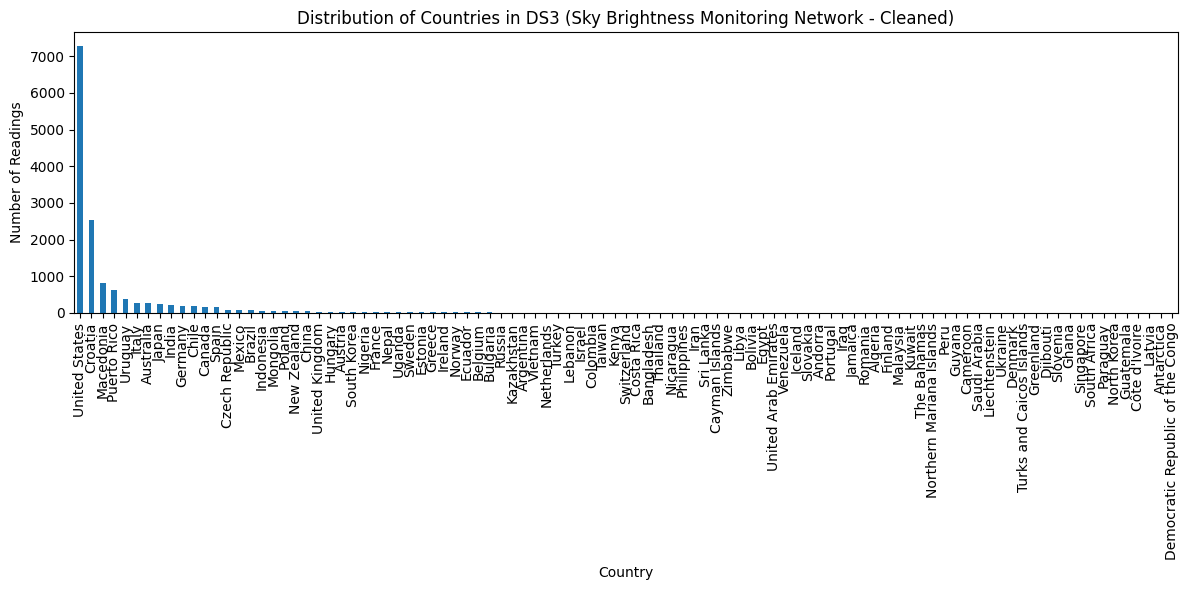

In [11]:
# prompt: Group the values in df_brightness["Country"] by country rather than distinct values. There are some values inside that take the form of "country - city". So, please use pattern extraction to extract the country first, then group the values in the "Country" attribute by country before plotting them in a bar graph (i.e. Visualize the count for each country as stored Country ordered in descending order)

# Function to extract country name, handling 'Country - City' format
def extract_country(country_name):
    if ' - ' in country_name:
        return country_name.split(' - ')[0]
    return country_name

# Apply the function to the 'Country' column to create a cleaned country column
df_brightness['Clean_Country'] = df_brightness['Country'].apply(extract_country)

# Calculate value counts for the cleaned country names and sort in descending order
cleaned_country_counts = df_brightness['Clean_Country'].value_counts().sort_values(ascending=False)

# Visualize the count for each cleaned country
plt.figure(figsize=(12, 6))
cleaned_country_counts.plot(kind='bar')
plt.title('Distribution of Countries in DS3 (Sky Brightness Monitoring Network - Cleaned)')
plt.xlabel('Country')
plt.ylabel('Number of Readings')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

We notice from the graph above that even though a large and diverse number of countries are included in the brightness dataset, the value distribution is very skewed, with most of the data being collected about the United States and Croatia. Also, inspecting the tail of the DataFrame will show that some countries include the city in the "Country" attribute. However, this inconsistent granularity does not pose much of a problem to our analysis since we can determine the city that the data entry belongs to using the latitude and longitude coordinates. As discussed in the exploration in DS1, we note that the coordinates are in Decimal Degree format, which we will have to take into account when complementing with other datasets in order to derive the city. We check if the brightness data is able to sufficiently complement our population data in DS1 by comparing the geographical coordinates in the following code cell. A tolerance of ±0.1° (approximately 11km) was chosen as it is small enough to reliably identify coordinates belonging to the same city, while accounting for minor variations in GPS recording between datasets.

Required info | Your answer
-------------------|------------------
GenAI tool name | Google Colab integrated code generator
Input prompt |  check the longitude and latitudes of df1 (left) against df_brightness (right). if the longitudes are within 0.1 degrees of each other and the latitudes are within 0.1 degrees of each other, consider them to be the same. use a left outer join. the new dataframe does not need to have longitude and latitude, only the city name.
Generated output |see comment in DS3 - code cell 4
Impacted notebook cell | DS3 - code cell 4

In [12]:
# prompt: check the longitude and latitudes of df1 (left) against df_brightness (right). if the longitudes are within 0.1 degrees of each other and the latitudes are within 0.1 degrees of each other, consider them to be the same. use a left outer join. the new dataframe does not need to have longitude and latitude, only the city name.

# Prepare df1 with city, lat, and lng
df1_temp = df1[['city', 'lat', 'lng']].copy()

# Prepare df_brightness with Latitude and Longitude
df_brightness_temp = df_brightness[['Latitude', 'Longitude']].copy()

# Add a dummy key for cross join
df1_temp['_key'] = 1
df_brightness_temp['_key'] = 1

# Perform a cross join (Cartesian product)
cross_joined_df = pd.merge(df1_temp, df_brightness_temp, on='_key').drop('_key', axis=1)

# Define the tolerance for latitude and longitude
tolerance = 0.1

# Apply the fuzzy matching conditions
fuzzy_matched_cities = cross_joined_df[
    (abs(cross_joined_df['lat'] - cross_joined_df['Latitude']) <= tolerance) &
    (abs(cross_joined_df['lng'] - cross_joined_df['Longitude']) <= tolerance)
]

# Select only the 'city' column from df1, as requested
# If a city from df1 matches multiple df_brightness_filtered entries, it will appear multiple times.
matched_cities_only = fuzzy_matched_cities[['city']]

print("Cities from df1 that have a fuzzy match in df_brightness:")
print(matched_cities_only)

Cities from df1 that have a fuzzy match in df_brightness:
                     city
13881               Tokyo
13882               Tokyo
13885               Tokyo
13886               Tokyo
13887               Tokyo
...                   ...
102590533  North Bethesda
102590534  North Bethesda
102600611       Montrouge
102604485       Montrouge
102898301          Severn

[8458 rows x 1 columns]


In [13]:
print(matched_cities_only['city'].nunique())

1038


This further inspection shows us that we are indeed able to match the geographical coordinates to 1038 unique cities, which will provide us with sufficient data for our analysis. The last step would be to check that these matched cities cover a sufficiently broad range of geographical areas in the form of continents.

Required info | Your answer
-------------------|------------------
GenAI tool name | Google Colab integrated code generator
Input prompt |  comparing using the 'country' attribute of fuzzy_matched_cities against continents, please map each entry in fuzzy_matched_cities to a Continent in continents. only print the columns "Continent" "city" and "ID"
Generated output |see comment in DS3 - code cell 5
Impacted notebook cell | DS3 - code cell 5

In [14]:
#prompt: comparing using the 'country' attribute of fuzzy_matched_cities against continents, please map each entry in fuzzy_matched_cities to a Continent in continents. only print the columns "Continent" "city" and "ID"

# Merge fuzzy_matched_cities with the 'df' DataFrame to get the Continent information
# We only need the 'city' and 'Continent' from df for merging
merged_with_continents = pd.merge(
    matched_cities_only,
    df[['city', 'Continent']].drop_duplicates(),
    on='city',
    how='left'
)

# Select the desired columns and remove any duplicate city-continent entries that might arise
final_output = merged_with_continents[['Continent', 'city']].drop_duplicates()

print("Fuzzy-matched cities with their corresponding continents:")
print(final_output)

Fuzzy-matched cities with their corresponding continents:
          Continent            city
0              Asia           Tokyo
63             Asia           Delhi
66             Asia          Mumbai
67             Asia          Manila
69    South America       São Paulo
...             ...             ...
9193  North America      Plainfield
9201  North America         Ashburn
9205  North America  North Bethesda
9213         Europe       Montrouge
9215  North America          Severn

[1091 rows x 2 columns]


In [15]:
# Checking for the geographical coverage of matched cities
print(final_output['Continent'].value_counts())

Continent
North America    541
Asia             245
Europe           189
South America     74
Africa            17
Oceania           12
Name: count, dtype: int64


We observe from the above cell that most of the matched cities are in North America, Asia or Europe, but since these are 3 very distinct regions and there is still some data on South America, Africa and Oceania, we can consider the dataset to be adequately varied in terms of geography, though we should still keep in mind the comparative lack of data for the African and Oceanic regions.

Additonally, for this dataset, the attribute "LimitingMag" is a measure of the light pollution in the area. A lower value means a larger extent of light pollution. We perform some data profiling to check if the merged dataset contains a varied range of areas with different brightness.

Required info | Your answer
-------------------|------------------
GenAI tool name | Google Colab integrated code generator
Input prompt |  comparing the entries in final_output with the attribute "LimitingMag" in df_brightness, please show the value distribution of "LimitingMag" in the form of a bar graph, with the x-axis being the values of "LimitingMag" and the y-axis being the number of times it occurs
Generated output |see comment in DS3 - code cell 7
Impacted notebook cell | DS3 - code cell 7

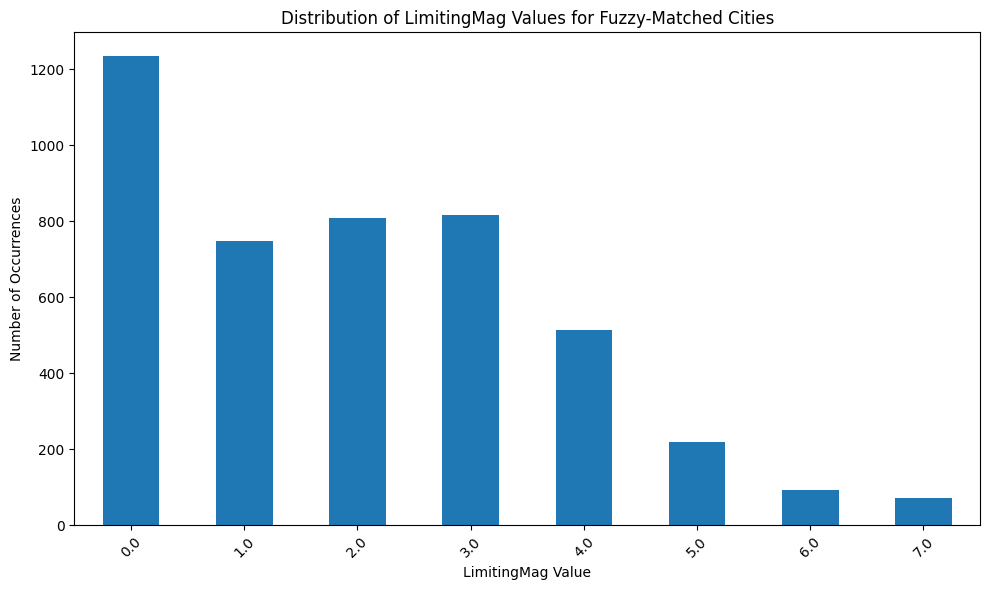

LimitingMag value counts for fuzzy-matched cities:
LimitingMag
0.0    1236
1.0     749
2.0     810
3.0     817
4.0     513
5.0     220
6.0      93
7.0      73
Name: count, dtype: int64


In [16]:
# prompt: comparing the entries in final_output with the attribute "LimitingMag" in df_brightness, please show the value distribution of "LimitingMag" in the form of a bar graph, with the x-axis being the values of "LimitingMag" and the y-axis being the number of times it occurs



# Create a temporary DataFrame to hold the latitude and longitude of matched brightness points
# Drop duplicates to ensure unique brightness points are considered for LimitingMag
matched_brightness_coords = fuzzy_matched_cities[['Latitude', 'Longitude']].drop_duplicates()

# Merge this with the original df_brightness to get the LimitingMag values for the matched points
# Using inner merge to only include points present in both (i.e., matched points)
df_matched_limitingmag = pd.merge(matched_brightness_coords, df_brightness[['Latitude', 'Longitude', 'LimitingMag']].drop_duplicates(),
                                  on=['Latitude', 'Longitude'],
                                  how='inner')

# Calculate the value counts for 'LimitingMag' from the matched data
limiting_mag_counts_matched = df_matched_limitingmag['LimitingMag'].value_counts().sort_index()

# Create a bar graph
plt.figure(figsize=(10, 6))
limiting_mag_counts_matched.plot(kind='bar')
plt.title('Distribution of LimitingMag Values for Fuzzy-Matched Cities')
plt.xlabel('LimitingMag Value')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print the counts for clarity
print("LimitingMag value counts for fuzzy-matched cities:")
print(limiting_mag_counts_matched)

We notice that the higher the value of LimitingMag (i.e. the lower the extent of light pollution and the darker the area is at night), the lower the number of data points in the dataset. There is significantly more data on bright areas than there are dark areas, so we have to keep that in mind when conducting our analysis. However, there are still a combined total of over 300 data points for the higher values of LimitingMag (5-7), so we should still be able to get a relatively comprehensive analysis.

**Quality considerations**



*   Completeness of this dataset is adequate for our task at hand. There is sufficient data across different countries, continents and cities with different levels of brightness at night, although we have to keep in mind that there is significantly more data for certain regions and brightness levels.
*   The dataset was also created using observations from 2024, which is recent enough to be relevant and also is not too different a time period from our other datasets, so the risk of inaccurate analysis due to using data from time periods that are too different is lowered.
* The dataset also comes from a reputable source, with the Globe at Night initiative being supported by credible organisations such as U.S. National Science Foundation NOIRLab and DarkSky International.


**Conclusion for Globe at Night - Sky Brightness Monitoring Network**

Overall, this dataset is adequate for our analysis as it provides us with sufficiently diverse data and combines with our other datasets to give us a database large enough to work with and derive conclusions from. However, a possible issue to take note of is that for some cities, there are multiple brightness observations taken. Thus, some form of aggregation will be required before performing a final analysis of the data.

### DS4: Cities with CCTV & Crime Index from Kaggle

**Description.** We downloaded the CSV file from Kaggle on 02/03/2026. It contains attributes such as city, country, number of CCTV Cameras, number of people, number of CCTV cameras per 1,000 people, cameras per square mile and crime index. A total of 8 unique attributes are present which are all highly relevant to our problem statement.

In [17]:
# Read the CSV file into a DataFrame
df_cctv = pd.read_csv('/content/drive/MyDrive/SC3021/DS4 Cities with CCTV & Crime Index.csv')
df_cctv = df_cctv.apply(safe_to_numeric)

# Print the first 5 rows of the DataFrame to verify it loaded correctly
print(df_cctv.tail(5))


       City       Country  # of CCTV Cameras  # of People  \
130  Riyadh  Saudi Arabia              150.0    7387817.0   
131  Abuja        Nigeria               40.0    3464123.0   
132  Bekasi     Indonesia               29.0    3510050.0   
133  Ibadan       Nigeria               10.0    3649023.0   
134   Lagos       Nigeria                0.0   14862111.0   

     # of CCTV Cameras per 1,000 People  Cameras per Square Mile  Crime Index  
130                                0.02                     0.22    26.990000  
131                                0.01                     0.01    59.570000  
132                                0.01                     0.35    35.849998  
133                                0.00                     0.00    50.080002  
134                                0.00                     0.00    65.360001  


We notice that the number of datapoints is significantly lower than that of our other datasets. For the brightness dataset, we had 1038 unique cities for which we could find a match for in our population dataset. However, this CCTV dataset only provides crime/CCTV data for 135 cities, even before we perform a join with the population dataset.

**Exploratory steps**

We perform a right outer join with the merged brightness and population dataset. This is to reveal if the two datasets are compatible so as to determine if they can be used to complement and enrich each other.

Required info | Your answer
-------------------|------------------
GenAI tool name | Google Colab integrated code generator
Input prompt |  comparing with the dataframe matched_cities_only (left), perform a right outer join on the column "City" in df_cctv (right) and the column "city" in matched_cities_only. the final dataframe should only have the attributes "City" (rename "city" in matched_cities_only to "City"), "# of CCTV Cameras", "# of CCTV Cameras per 1000 people", "Cameras per Square Mile" and "Crime Index". delete any duplicate entries for cities, so each unique value of "City" should only appear once in the merged dataframe
Generated output |see comment in DS4 - code cell 2
Impacted notebook cell | DS4 - code cell 2

In [18]:
# prompt: comparing with the dataframe matched_cities_only (left), perform a right outer join on the column "City" in df_cctv (right) and the column "city" in matched_cities_only. the final dataframe should only have the attributes "City" (rename "city" in matched_cities_only to "City"), "# of CCTV Cameras", "# of CCTV Cameras per 1000 people", "Cameras per Square Mile" and "Crime Index". delete any duplicate entries for cities, so each unique value of "City" should only appear once in the merged dataframe

# Rename 'city' column in matched_cities_only to 'City' for merging
matched_cities_only_renamed = matched_cities_only.rename(columns={'city': 'City'})

# Perform a right outer join
cctv_matched_cities = pd.merge(
    matched_cities_only_renamed,
    df_cctv,
    on='City',
    how='right'
)

# Select the required columns
final_cctv_df = cctv_matched_cities[[
    'City',
    '# of CCTV Cameras',
    '# of CCTV Cameras per 1,000 People',
    'Cameras per Square Mile',
    'Crime Index'
]]

# Remove duplicate entries based on the 'City' column and reset the index
final_cctv_df = final_cctv_df.drop_duplicates(subset=['City']).reset_index(drop=True)

print(final_cctv_df.tail())

       City  # of CCTV Cameras  # of CCTV Cameras per 1,000 People  \
130  Riyadh              150.0                                0.02   
131  Abuja                40.0                                0.01   
132  Bekasi               29.0                                0.01   
133  Ibadan               10.0                                0.00   
134   Lagos                0.0                                0.00   

     Cameras per Square Mile  Crime Index  
130                     0.22    26.990000  
131                     0.01    59.570000  
132                     0.35    35.849998  
133                     0.00    50.080002  
134                     0.00    65.360001  



After merging, we observe that we are able to find matching data in the merged brightness and population dataset for all the cities in the CCTV dataset, so the CCTV dataset is able to complement our other existing datasets for analysis.


Next, we check for the geographical spread of the cities included in the CCTV dataset.

Required info | Your answer
-------------------|------------------
GenAI tool name | Google Colab integrated code generator
Input prompt |  Categorise cities by countries first by renaming "Country" to "country" to merge with the df continents. Afterwards, count number of countries per continent
Generated output |see comment in DS4 - code cell 3


Number of unique continents represented in the CCTV data: 6

Distribution of cities by continent in the CCTV dataset:
Continent
Asia             76
Africa           19
South America    16
North America     9
Europe            8
Oceania           2
Name: count, dtype: int64


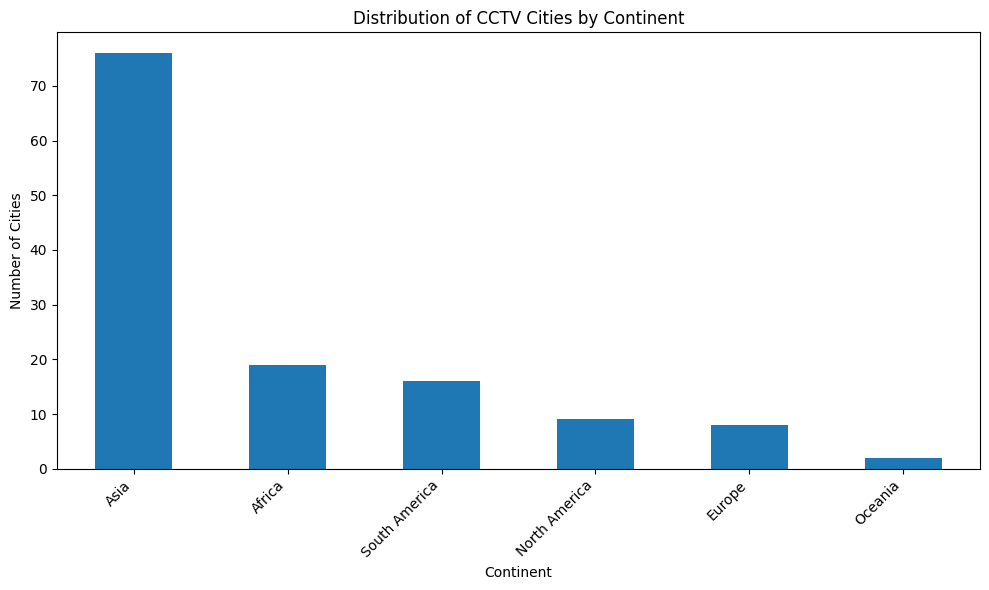

In [19]:
#prompt: Categorise cities by countries first by renaming "Country" to "country" to merge with the df continents. Afterwards, count number of countries per continent


# Merge final_cctv_df with the original df_cctv to get the 'Country' column back
# We'll use 'City' as the key and keep only necessary columns from df_cctv
cctv_with_country = pd.merge(final_cctv_df, df_cctv[['City', 'Country']], on='City', how='left').drop_duplicates(subset=['City'])

# Rename 'Country' column to 'country' for merging with the continents DataFrame
cctv_with_country_renamed = cctv_with_country.rename(columns={'Country': 'country'})

# Merge with the continents DataFrame
merged_cctv_continents = pd.merge(cctv_with_country_renamed, continents, on='country', how='left')

# Count the number of cities per continent
continent_counts_cctv = merged_cctv_continents['Continent'].value_counts()

print("Number of unique continents represented in the CCTV data:", merged_cctv_continents['Continent'].nunique())
print("\nDistribution of cities by continent in the CCTV dataset:")
print(continent_counts_cctv)

# Create a histogram (bar graph) of the continent distribution
plt.figure(figsize=(10, 6))
continent_counts_cctv.plot(kind='bar')
plt.title('Distribution of CCTV Cities by Continent')
plt.xlabel('Continent')
plt.ylabel('Number of Cities')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Based on the distribution of cities by continent in the CCTV dataset, it reveals that most of the data covers cities in Asia. For North America, Europe and Oceania, we only have CCTV data on less than 10 cities.

**Data quality considerations**



*   Completeness of this dataset is inadequate for our task at hand. There is insufficient data across different countries, continents and cities as seen from the bar graph above.
*   The dataset was also created using observations from 2022, which is relatively recent enough to be relevant. However, we do note that there is a slight time period discrepancy for this dataset with the rest of the data sets, but since the discrepancy is still within a three-year margin, we deem it to be acceptable since it is likely that there would not have been very significant changes to the data within that time period.
* The interpretability of the dataset is high with limited but crucial attributes with explicit semantics. This reduces the likeliness of misinterpretation and misuse during analysis.
* The dataset was found on Kaggle and originally sourced from Comparitech, which conducts independent research on  a wide range of topics related to security, including surveillance. This makes the source generally trustworthy.


**Conclusion for Kaggle Cities with CCTV & Crime Index data set.**

Overall, we do understand the limitations that the dataset poses in terms of the mismatch of the year that the data was collected relative to the other datasets, as well as its limited number of data points. However, we were unable to find a dataset on the number of CCTVs at the granularity of the the city level, and out of all the datasets that we could find, DS4 is the one that covers the widest geographical range of cities. We also note that CCTV camera count is relatively more difficult to find accurate data for since most cameras are privately owned by businesses and homes rather than publicly owned by governments, and there is no centralised registry, especially across different cities in different countries. There are also security concerns when it comes to data on surveillance systems, so this data is not readily available. However, the number of CCTVs in a city is a highly relevant factor that directly affects crime rates, and so we choose to still include this factor in our analysis. Thus, we will proceed with this limited dataset, but will keep in mind these facts during the data preparation and analysis:

*  Year difference between datasets may pose temporal mismatch and inconsistency in analysis due to potential changes in data over the years when merging datasets.
*  With the large number of missing data values due to limited number of data across cities, it may lead to limited accuracy and cause potential bias.

### DS5: World Crime Index

**Description**. This dataset was downloaded from a CSV file from Kaggle on 02/03/2026. It provides records of crime rankings for cities worldwide with attributes such as rank, city, country, crime index and safety index. The code below imports the data into a DataFrame and displays the first few rows showing a glimpse of the data.

In [20]:
# Get table data from the csv file about world crime index, using the file mounted in Google Drive

# Read in the csv file into a DataFrame
df5 = pd.read_csv('/content/drive/MyDrive/SC3021/DS5 World Crime Index.csv')
df5 = df5.apply(safe_to_numeric)

# Print the first 5 rows of the DataFrame to verify it loaded correctly
print(df5.head())

   Rank          City            Country  Crime Index  Safety Index
0   1.0       Caracas          Venezuela    83.599998     16.400000
1   2.0      Pretoria       South Africa    82.000000     18.000000
2   3.0        Durban       South Africa    81.000000     19.000000
3   4.0  Port Moresby   Papua New Guinea    80.699997     19.299999
4   5.0  Johannesburg       South Africa    80.699997     19.299999


Looking at this data, we examine that there are 2 attributes that are not necessary in our analysis, namely Rank and Safety Index. Hence we proceed to remove them and keep only City, Country and Crime Index in the dataframe for analysis.

In [21]:
# Keep only 'City', 'Country', and 'Crime Index' columns in df5
df5 = df5[['City', 'Country', 'Crime Index']]

# Display the first 5 rows to see the changes
print(df5.head())

           City            Country  Crime Index
0       Caracas          Venezuela    83.599998
1      Pretoria       South Africa    82.000000
2        Durban       South Africa    81.000000
3  Port Moresby   Papua New Guinea    80.699997
4  Johannesburg       South Africa    80.699997


Now, we will examine if there is a sufficient range of cities and countries covered.

In [22]:
# Get the metadata on number of unique cities represented
print("Total number of unique cities: ", df5["City"].nunique(), "\n")

# Get the metadata on number of unique countries represented
print("Total number of unique countries: ", df5["Country"].nunique(), "\n")

Total number of unique cities:  412 

Total number of unique countries:  141 



From the numbers we derived, we can see that there is sufficient number of unique cities and a significant number of countries (141) in our dataset, which will allow for for diverse analysis. However, to ensure an even broader coverage of cities of countries around the globe, we will now see the distribution of the countries based on its continents.

This is done once again by merging this crime index dataframe with the continent dataframe. We note that we have to change the attribute "Country" in the crime index dataframe to "country" to match the attribute label in the continent dataframe when we perform the merger using a left outer join. Upon further inspection, we realise that there is a difference in the text casing of the letters for the countries as well as some trailing white spaces for certain rows. Hence, we will remove all whitespaces and standardise all letters to lowercase for a successful join. To better aid visualisation of the geographical spread, we will use a bar graph to portray the data.

Required info | Your answer
-------------------|------------------
GenAI tool name | Google Colab integrated code generator
Input prompt | rename the 'Country' column in ds5 to 'country' and standardise both new ds5 dataframe and continents dataframe by stripping all whitespaces and making all letters lowercase. Afterwards, do a left outer join merge on both dataframes and provide the count of cities for each continent. Also provide the number of cities with correct matches and number of mismatches plot a histogram graph on this.
Generated output |see comments in DS5 - code cell 4



Number of unique continents represented in the crime index data: 6

Distribution of cities by continent in the crime index dataset:
Continent
Europe           155
Asia              83
North America     54
South America     26
Oceania           23
Africa            17
Name: count, dtype: int64

Total number of cities with a continent match: 358
Total number of cities without a continent match: 58


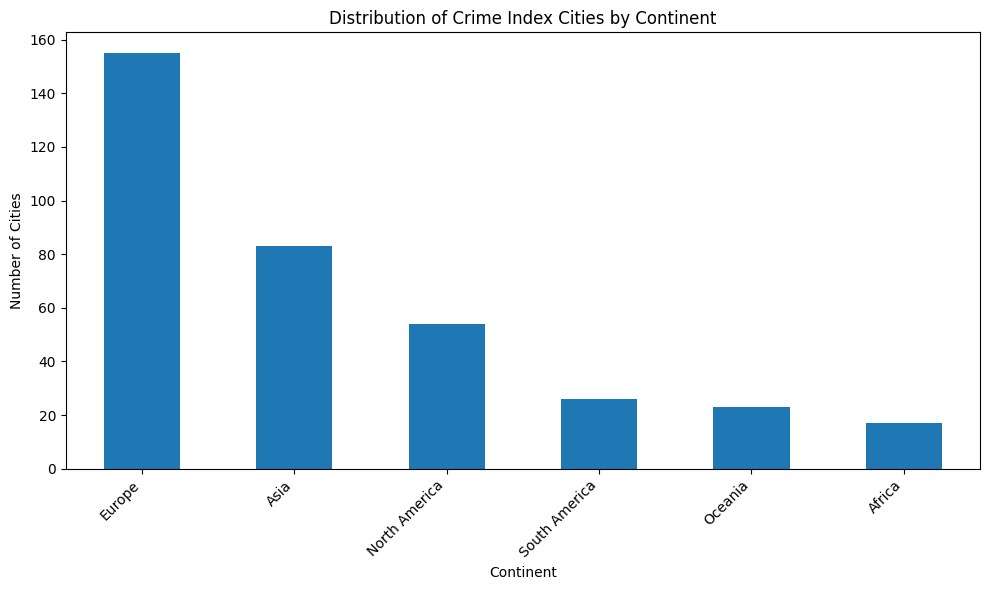

In [23]:
# prompt: rename the 'Country' column in ds5 to 'country' and standardise both new ds5 dataframe and continents dataframe by stripping all whitespaces and making all letters lowercase. Afterwards, do a left outer join merge on both dataframes and provide the count of cities for each continent. Also provide the number of cities with correct matches and number of mismatches plot a histogram graph on this

# Rename 'Country' column in df5 to 'country' to match the continents DataFrame
df5_renamed = df5.rename(columns={'Country': 'country'})

# Standardize country names in df5_renamed: strip whitespace and convert to lowercase
df5_renamed['country'] = df5_renamed['country'].str.strip().str.lower()

# Standardize country names in continents: strip whitespace and convert to lowercase
continents_cleaned = continents.copy()
continents_cleaned['country'] = continents_cleaned['country'].str.strip().str.lower()

# Merge df5_renamed with the cleaned continents DataFrame
merged_crime_continents = pd.merge(df5_renamed, continents_cleaned, on='country', how='left')

# Count the number of cities per continent, dropping NaN to only count successful merges
continent_counts_crime = merged_crime_continents['Continent'].value_counts()

# Calculate total number of cities with a match
total_matched_cities = continent_counts_crime.sum()

# Calculate total number of cities without a match (where Continent is NaN)
total_unmatched_cities = merged_crime_continents['Continent'].isnull().sum()

print("\nNumber of unique continents represented in the crime index data:", merged_crime_continents['Continent'].nunique())
print("\nDistribution of cities by continent in the crime index dataset:")
print(continent_counts_crime)
print(f"\nTotal number of cities with a continent match: {total_matched_cities}")
print(f"Total number of cities without a continent match: {total_unmatched_cities}")

# Create a histogram (bar graph) of the continent distribution
plt.figure(figsize=(10, 6))
if not continent_counts_crime.empty:
    continent_counts_crime.plot(kind='bar')
    plt.title('Distribution of Crime Index Cities by Continent')
    plt.xlabel('Continent')
    plt.ylabel('Number of Cities')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("\nNo continent data available to plot a histogram after cleaning and merging.")

The graph and numbers reveal that there is sufficient coverage of data across continents. However, the data is quite Euro-centric and  there are significantly less data points for South America, Oceania and Africa. We also note that there are 58 countries that were unable to find a match with a corresponding continent, plausibly due to missing data in the continent dataframe, which highlights there is greater coverage of countries for this particular dataset.

We now perform a full outer join with the dataset that we obtained from merging the population and brightness data, so as to get an idea of the extent of overlapping data points for these 3 datasets.

Required info | Your answer
-------------------|------------------
GenAI tool name | Google Colab integrated code generator
Input prompt | for each unique value of "city" in matched_cities_only, only keep one record. so if the same city name appears twice, drop any duplicate records and only keep one record of the city name. this new dataframe should only have the index and the city. in this new dataframe, do a full outer join with the "City" attribute in df5 (rename "City" to "city" before performing the join). the final merged dataframe is to only have the attributes "city", "Country" and "Crime Index" then print the number of rows that have a match across this two dataframes, and also print the total number of null values.
Generated output |see comments in DS5 - code cell 5


In [24]:
# prompt: for each unique value of "city" in matched_cities_only, only keep one record. so if the same city name appears twice, drop any duplicate records and only keep one record of the city name. this new dataframe should only have the index and the city. in this new dataframe, do a full outer join with the "City" attribute in df5 (rename "City" to "city" before performing the join). the final merged dataframe is to only have the attributes "city", "Country" and "Crime Index" then print the number of rows that have a match across this two dataframes, and also print the total number of null values

# 1. For each unique value of 'city' in matched_cities_only, only keep one record.
# This new dataframe should only have the 'city' column.
matched_cities_unique = matched_cities_only[['city']].drop_duplicates().reset_index(drop=True)

# 2. Rename 'City' attribute in df5 to 'city' for merging
df5_renamed = df5.rename(columns={'City': 'city'})

# 3. Perform a full outer join with df5 on the 'city' attribute
# Use indicator=True to see merge origins
merged_df_temp = pd.merge(df5_renamed, matched_cities_unique, on='city', how='outer', indicator=True)

# 4. The final merged dataframe is to only have the attributes 'city', 'Country' and 'Crime Index'
final_merged_df = merged_df_temp[['city', 'Country', 'Crime Index']]

# 5. Print the number of rows that have a match across the two dataframes
num_matched_in_both = merged_df_temp[merged_df_temp['_merge'] == 'both'].shape[0]
print(f"Number of rows with matching 'city' across both dataframes: {num_matched_in_both}")

# 6. Print the total number of null values in the final merged dataframe
total_null_values = final_merged_df.isnull().sum().sum()
print(f"Total number of null values in the final merged dataframe: {total_null_values}")

# Display the head of the final merged dataframe for inspection (optional)
print("\nHead of the final merged dataframe:")
print(final_merged_df.head())


Number of rows with matching 'city' across both dataframes: 150
Total number of null values in the final merged dataframe: 1782

Head of the final merged dataframe:
       city          Country  Crime Index
0    Aachen              NaN          NaN
1   Aalborg          Denmark    24.799999
2     Aalst              NaN          NaN
3  Aberdeen   United Kingdom    33.799999
4     Abiko              NaN          NaN


We notice that after the full outer join, there are a lot of null values, suggesting that the Crime Index dataset has less available datapoints compared to the merged population and brightness dataset. We now remove all the null values from the merged dataframe.

Required info | Your answer
-------------------|------------------
GenAI tool name | Google Colab integrated code generator
Input prompt | If a row has any null values in final_merged_df, remove the row from the dataframe. Print the new dataframe that has no null values and also reset the index
Generated output |see comments in DS5 - code cell 6


In [25]:
# prompt: If a row has any null values in final_merged_df, remove the row from the dataframe. Print the new dataframe that has no null values and also reset the index

# Remove rows with any null values from final_merged_df and reset the index
final_merged_df_cleaned = final_merged_df.dropna().reset_index(drop=True)

# Print the new dataframe that has no null values
print("DataFrame after removing rows with any null values and resetting index:")
print(final_merged_df_cleaned.head())
print(f"Total number of rows after dropping nulls: {len(final_merged_df_cleaned)}")

DataFrame after removing rows with any null values and resetting index:
          city                Country  Crime Index
0      Aalborg                Denmark    24.799999
1     Aberdeen         United Kingdom    33.799999
2    Abu Dhabi   United Arab Emirates    11.200000
3  Addis Ababa               Ethiopia    49.299999
4     Adelaide              Australia    31.100000
Total number of rows after dropping nulls: 416


We observe that the total number of rows with non-null values is 416, which means that for every city in the crime index dataset, we also have corresponding population and brightness data. Thus, the crime index dataset is compatible with our existing datasets on population and brightness. As a final check, we will see if it also complements the CCTV camera data.

Required info | Your answer
-------------------|------------------
GenAI tool name | Google Colab integrated code generator
Input prompt | rename "City" in final_cctv_df to "city" and perform an inner join between final_cctv_df and final_merged_df_cleaned on the attribute "city". print the total number of rows. drop any duplicate values for city and reset the index
Generated output |see comments in DS5 - code cell 7


In [26]:
# prompt: rename "City" in final_cctv_df to "city" and perform an inner join between final_cctv_df and final_merged_df_cleaned on the attribute "city". print the total number of rows. drop any duplicate values for city and reset the index

# Rename 'City' in final_cctv_df to 'city'
final_cctv_df_renamed = final_cctv_df.rename(columns={'City': 'city'})

# Perform an inner join between final_cctv_df_renamed and final_merged_df_cleaned on 'city'
merged_cctv_crime_brightness = pd.merge(
    final_cctv_df_renamed,
    final_merged_df_cleaned,
    on='city',
    how='inner'
)

# Drop duplicate values for city and reset the index
merged_cctv_crime_brightness = merged_cctv_crime_brightness.drop_duplicates(subset=['city']).reset_index(drop=True)

# Print the head of the dataframe
print(merged_cctv_crime_brightness.head())

# Print the total number of rows in the joined and deduplicated dataframe
print(f"Total number of rows after inner join and dropping duplicates: {len(merged_cctv_crime_brightness)}")

        city  # of CCTV Cameras  # of CCTV Cameras per 1,000 People  \
0     London           691000.0                           73.309998   
1     Indore           200600.0                           64.430000   
2    Beijing          1150000.0                           55.029999   
3  Hyderabad           375000.0                           36.520000   
4   Shanghai          1000000.0                           35.980000   

   Cameras per Square Mile  Crime Index_x          Country  Crime Index_y  
0              1138.479980      53.070000   United Kingdom      53.799999  
1               133.289993      49.880001            India      48.799999  
2               181.490005      34.450001            China      28.400000  
3               133.839996      43.779999            India      43.200001  
4               408.489990      34.790001            China      30.600000  
Total number of rows after inner join and dropping duplicates: 75


We notice that the CCTV data is not as compatible with the Crime Index data for two reasons. Firstly, there are only 75 records that match, which is a relatively small set of matching records. Secondly, we notice that there is significant discrepancy between the crime indices for some records, so we will either require some aggregation or choose to ignore the crime index attribute from the CCTV dataset and only use the crime index attribute from the Crime Index dataset.

**Quality consideration**

From the above exploration of the dataset, we make the following observations in terms of data quality:


* In terms of completeness, although the dataset has data on countries across continents, it is not a very equal spread of data since most data is data on European cities.
* The interpretability of the dataset is also high given that it has few and clear data attributes, making the semantics clear and easy to analyse , so the likelihood of misuse and misinterpretation is unlikely.
* The year the dataset was revised was back in 2023 which may be slightly outdated. This highlights the issue of relevance when we derive conclusions from analysis. However, since the timeframe is not too far off from other datasets we have, it is still highly applicable for our analysis.
* The data source is derived from Numbeo which is a crowd-sourced database. Since the data can be altered by users and is not peer-reviewed, the data may not be reliable.



**Concluding for DS5 World Crime Index dataset**

Overall, the data of DS5 is able to provide us with a rather comprehensive source of crime indices across cities and countries, but Because the dataset contains significantly more observations from Europe than from other continents, there is a potential Eurocentric bias. This imbalance may affect the generalizability of the analysis, so conclusions applied to non-European countries should be interpreted with caution. We also have to ensure that we take into account the time difference in terms of the year in which the data was updated when we make links after analysis, so as to derive a valid and more accurate conclusion. Even though the data is not exactly compatible with our CCTV dataset, it is still able to complement our brightness and population datasets very well, and is also the most recent dataset on crime index that we could find which also spans a wide geographic range of cities. Regarding the reliability of the dataset, although there is a significant possibility that the data may not be entirely reliable due to the crowd-sourced nature of the data, we can cross reference the crime index values with the Crime Index attribute in our CCTV dataset and see if the average discrepancy is large. If the discrepancy is within an acceptable range, we can assume that the data in this dataset is sufficiently reliable. Hence, it is the most optimal dataset that we can use for our analysis despite its shortcomings.



### DS6: Countries by Continent dataset

**Description**. The kaggle dataset, downloaded on 02/03/2026, contains data that links countries to their continents. As seen in the previous few datasets, we have been using DS6 just to check if the other datasets have a good distribution and range of data that covers cities around the world. Since this dataset is not used in any analysis or conclusion, we would not be going into detail for its quality considerations.

In [27]:
# Displaying the dataframe
print(continents.head(), "\n")

print(continents.tail())

  Continent   country
0    Africa   Algeria
1    Africa    Angola
2    Africa     Benin
3    Africa  Botswana
4    Africa   Burkina 

         Continent    country
191  South America   Paraguay
192  South America       Peru
193  South America   Suriname
194  South America    Uruguay
195  South America  Venezuela




### DS7: Global Administrative Areas (GADM) dataset

**Description**. The Global Administrative Areas (GADM) Dataset was downloaded on 02/03/26. This dataset provides maps and spatial data for all countries and their sub-divisions in high resolution. It includes crucial attributes that are necessary for us to derive the area of cities through the precise geometry data values. The following code opens the file and shows the first five rows of the dataset to ensure the file was imported and opened correctly

Required info | Your answer
-------------------|------------------
GenAI tool name | ChatGPT
Input prompt | Help me open the GPKG file on GADM and note that I am opening it in google collab. Print the first 5 rows of the table
Generated output |see comments in DS7 - code cell 1


In [28]:
# prompt: Help me open the GPKG file on GADM and note that I am opening it in google collab. Print the first 5 rows of the table

# Open gadm file in google collab
gpkg_path = '/content/drive/MyDrive/SC3021/gadm_410.gpkg'
layers = fiona.listlayers(gpkg_path)
gdf = gpd.read_file(gpkg_path, layer=layers[0])

# Print first 5 rows of table
print("Number of rows:", len(gdf))
gdf.head()

Number of rows: 356508


,UID,GID_0,NAME_0,VARNAME_0,GID_1,NAME_1,VARNAME_1,NL_NAME_1,ISO_1,HASC_1,...,ENGTYPE_5,GOVERNEDBY,SOVEREIGN,DISPUTEDBY,REGION,VARREGION,COUNTRY,CONTINENT,SUBCONT,geometry
0,1,AFG,Afghanistan,,AFG.1_1,Badakhshan,Badahšan,,,AF.BD,...,,,Afghanistan,,,,Afghanistan,Asia,,"MULTIPOLYGON (((71.41149 36.55717, 71.40954 36..."
1,2,AFG,Afghanistan,,AFG.1_1,Badakhshan,Badahšan,,,AF.BD,...,,,Afghanistan,,,,Afghanistan,Asia,,"MULTIPOLYGON (((71.2762 38.00465, 71.27578 38...."
2,3,AFG,Afghanistan,,AFG.1_1,Badakhshan,Badahšan,,,AF.BD,...,,,Afghanistan,,,,Afghanistan,Asia,,"MULTIPOLYGON (((70.78272 37.27678, 70.78635 37..."
3,4,AFG,Afghanistan,,AFG.1_1,Badakhshan,Badahšan,,,AF.BD,...,,,Afghanistan,,,,Afghanistan,Asia,,"MULTIPOLYGON (((71.41149 36.55717, 71.40091 36..."
4,5,AFG,Afghanistan,,AFG.1_1,Badakhshan,Badahšan,,,AF.BD,...,,,Afghanistan,,,,Afghanistan,Asia,,"MULTIPOLYGON (((70.71236 37.07621, 70.73582 37..."


We observe that there are 356,508 rows of data. Additionally, through observation of the data, we realised that the column named "NAME_2" refers to the city name. To avoid confusion, we will rename the column header to "CITY" and remove all other columns which are not necessary for analysis. This leaves us with columns: City, Country and Geometry. We print the first 5 rows to ensure that this is done properly.

In [29]:
gdf = gdf[["COUNTRY", "NAME_2", "geometry"]].copy()
gdf = gdf.rename(columns={"NAME_2": "CITY"})

gdf.head()

,COUNTRY,CITY,geometry
0,Afghanistan,Baharak,"MULTIPOLYGON (((71.41149 36.55717, 71.40954 36..."
1,Afghanistan,Darwaz,"MULTIPOLYGON (((71.2762 38.00465, 71.27578 38...."
2,Afghanistan,Fayzabad,"MULTIPOLYGON (((70.78272 37.27678, 70.78635 37..."
3,Afghanistan,Ishkashim,"MULTIPOLYGON (((71.41149 36.55717, 71.40091 36..."
4,Afghanistan,Jurm,"MULTIPOLYGON (((70.71236 37.07621, 70.73582 37..."


To ensure that this dataset has a wide range and distribution of city values, we have to check for the number of unique values for data under "CITY" and "COUNTRY". Upon further inspection, we noticed that there are some null values under the "Country" and "Name_2" columns. For this, we will proceed to remove the rows with those missing values as they will not be used in our analysis.


In [30]:
# Remove rows where either COUNTRY or CITY is missing
temp = gdf[["COUNTRY", "CITY"]].dropna().copy()

# Convert COUNTRY and CITY columns to strings and remove whitespace
temp["COUNTRY"] = temp["COUNTRY"].astype(str).str.strip()
temp["CITY"] = temp["CITY"].astype(str).str.strip()

# Remove rows where COUNTRY or CITY is an empty string after stripping
temp = temp[(temp["COUNTRY"] != "") & (temp["CITY"] != "")]

print("Total countries:", len(temp["COUNTRY"]))
print("Total cities:", len(temp["CITY"]))
print("Unique countries:", temp["COUNTRY"].nunique())
print("Unique cities:", temp["CITY"].nunique())

Total countries: 355697
Total cities: 355697
Unique countries: 171
Unique cities: 42692


Based on the total number of unique cities and countries, we note that this dataset contains a huge number of duplicated cities. Due to this, we will proceed to check if the duplicates of each city have the same geometry value.


Required info | Your answer
-------------------|------------------
GenAI tool name | ChatGPT
Input prompt | For the duplicated cities in the dataset, help me check if there the geometry value are the same if the city and country names are the same. Remove any rows with missing values under attributes "COUNTRY " and "CITY". Print the final count for number of city-country duplicates with same and different geometry values.
Generated output |see comments in DS7 - code cell 4


In [31]:
#prompt: For the duplicated cities in the dataset, help me check if there the geometry value are the same if the city and country names are the same. Remove any rows with missing values under attributes "COUNTRY " and "CITY". Print the final count for number of city-country duplicates with same and different geometry values.
# Find duplicate COUNTRY-CITY pairs first
dup_keys = (
    gdf[["COUNTRY", "CITY"]]
    .dropna()
    .assign(
        COUNTRY=lambda x: x["COUNTRY"].astype(str).str.strip(),
        CITY=lambda x: x["CITY"].astype(str).str.strip()
    )
)

dup_keys = dup_keys[(dup_keys["COUNTRY"] != "") & (dup_keys["CITY"] != "")]
dup_keys = dup_keys[dup_keys.duplicated(subset=["COUNTRY", "CITY"], keep=False)]

# Keep only duplicate rows from the full dataframe
dup_geom = gdf.merge(dup_keys.drop_duplicates(), on=["COUNTRY", "CITY"], how="inner")[["COUNTRY", "CITY", "geometry"]].copy()

# Compare geometry values
dup_geom["geometry_wkb"] = dup_geom["geometry"].apply(lambda x: x.wkb)

geom_check = (
    dup_geom.groupby(["COUNTRY", "CITY"])["geometry_wkb"]
    .nunique()
    .reset_index(name="num_unique_geometry")
)

same_geometry_count = (geom_check["num_unique_geometry"] == 1).sum()
different_geometry_count = (geom_check["num_unique_geometry"] > 1).sum()

print("Number of duplicate city-country groups with the same geometry value:", same_geometry_count)
print("Number of duplicate city-country groups with different geometry values:", different_geometry_count)

Number of duplicate city-country groups with the same geometry value: 0
Number of duplicate city-country groups with different geometry values: 11442


Based on the results, every duplicate has a different geometry value for a specific city. Hence, we have to take note of this when we use geometry to derive the specific area of a city so that we only derive one specific accurate area value per city.

To evaluate whether DS7 can be integrated with population data from DS1, we assess the overlap between the two datasets using shared city–country pairs. This is done via an inner join, with the number of matched records indicating the degree of compatibility between the datasets.

Required info | Your answer
-------------------|------------------
GenAI tool name | Google colab integrated code generator
Input prompt | Perform a inner join for DS1 and DS7 to generate a new table and print out the number of unique countries and cities after the join
Generated output |see comments in DS7 - code cell 5


In [32]:
#prompt: Perform a inner join for DS1 and DS7 to generate a new table and print out the number of unique countries and cities after the join

# Extract unique city and country pairs from DS7 (gdf), excluding rows with missing values
unique_ds7_cities = gdf[['COUNTRY', 'CITY']].dropna().drop_duplicates().copy()

# Standardize to ensure empty strings are also excluded
unique_ds7_cities['COUNTRY'] = unique_ds7_cities['COUNTRY'].astype(str).str.strip()
unique_ds7_cities['CITY'] = unique_ds7_cities['CITY'].astype(str).str.strip()
unique_ds7_cities = unique_ds7_cities[
    (unique_ds7_cities['COUNTRY'] != '') & (unique_ds7_cities['CITY'] != '')
]

# Match DS1 column names for merge
unique_ds7_cities.columns = ['country', 'city']

# Perform an inner join with DS1 (df1) to find common cities
linked_cities = pd.merge(df1, unique_ds7_cities, on=['city', 'country'], how='inner')

# Count the results
num_unique_links = linked_cities.shape[0]

print(f"Number of unique cities in DS7 that are also in DS1: {num_unique_links}")
print(f"Number of unique countries in filtered DS7: {unique_ds7_cities['country'].nunique()}")


Number of unique cities in DS7 that are also in DS1: 2816
Number of unique countries in filtered DS7: 171


After performing a inner join, we note that only 2816 cities out of the original 6901 in DS1 have corresponding area data in DS7. Despite this, 2816 number of cities is still a substantial amount of data to be used for our analysis. However, we still have to check there is sufficient geographical coverage of cities across the world. To do this, we will merge this DS7 with DS6 to check the spread of the 171 unique countries across continents around the world.


Required info | Your answer
-------------------|------------------
GenAI tool name | ChatGPT
Input prompt | Help me merge DS6 and DS7 through an inner join and plot a histogram to see the spread of data. Provide the number of unmatched data between the 2 datasets and print the number of countries per continent
Generated output |see comments in DS7 - code cell 6


Number of unmatched countries (not in DS6): 22
Number of unique countries per continent in DS7:
Continent
Africa           43
Europe           38
Asia             36
South America    12
North America    11
Oceania           9
Name: country, dtype: int64


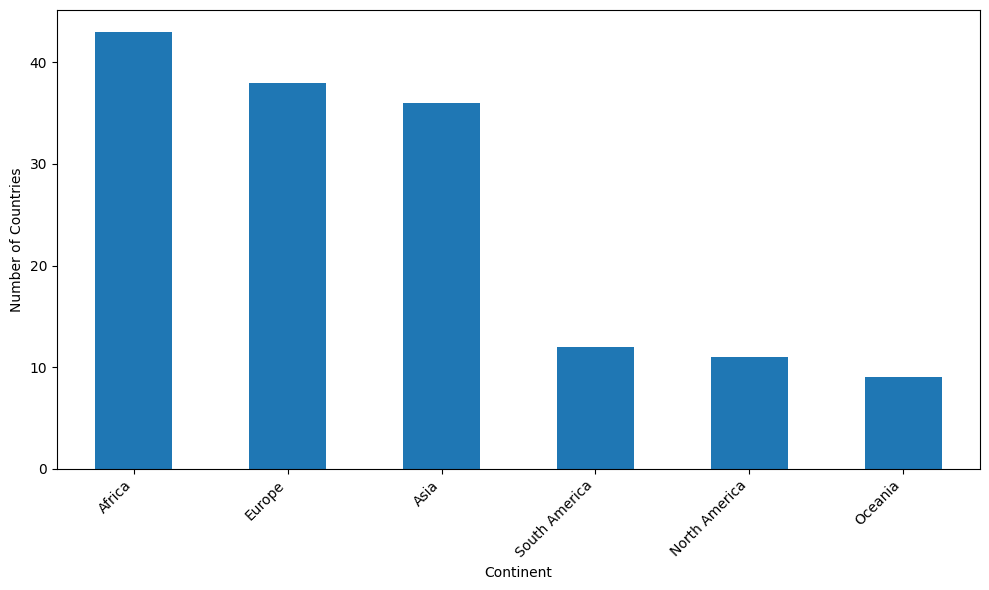

In [33]:
#prompt:  Help me merge DS6 and DS7 through an inner join and plot a histogram to see the spread of data. Provide the number of unmatched data between the 2 datasets and print the number of countries per continent

# Create a copy of the unique DS7 city-country pairs
ds7_unique_cities = unique_ds7_cities.copy()

# Standardize country names by stripping whitespace and converting to lowercase
ds7_unique_cities['country'] = ds7_unique_cities['country'].str.strip().str.lower()

# Create a copy of the continents DataFrame
continents_cleaned = continents.copy()

# Rename 'Country' to 'country' so both DataFrames use the same column name
continents_cleaned = continents_cleaned.rename(columns={'Country': 'country'})

# Standardize country names in the continents DataFrame
continents_cleaned['country'] = continents_cleaned['country'].str.strip().str.lower()

# Merge DS7 countries with continent information
merged_ds7_continents = pd.merge(ds7_unique_cities, continents_cleaned, on='country', how='left')

# Count the number of unique countries in DS7 for each continent
continent_country_counts = (
    merged_ds7_continents.groupby('Continent')['country']
    .nunique()
    .sort_values(ascending=False)
)

# Find DS7 countries that did not match any continent
unmatched_countries = merged_ds7_continents[merged_ds7_continents['Continent'].isnull()]['country'].unique()
num_unmatched_countries = len(unmatched_countries)

print(f"Number of unmatched countries (not in DS6): {num_unmatched_countries}")
print("Number of unique countries per continent in DS7:")
print(continent_country_counts)

# Plot the number of unique DS7 countries by continent
plt.figure(figsize=(10, 6))
continent_country_counts.plot(kind='bar')
plt.xlabel('Continent')
plt.ylabel('Number of Countries')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

From the results, we note that there are 22 countries that are unable to be matched to a continent but for the other 149 countries, they are spread out across continents. This shows a good spread and distribution of values for cities globally.

**Data quality considerations**

We highlight the following quality criteria that we assessed (among others) to determine the suitability of the dataset for our task:


*   In terms of completeness, the dataset satisfies our requirement as it is rather comprehensive in terms of the geographical coverage, which will allow us to reduce region-centric bias.
*   The interpretability of the dataset is rather high after we remove unneccessary columns, keeping the crucial ones that are needed for enriching and calculation. This reduces the chances of misinterpreting data and minimises error during data analysis.
* GADM (Database of Global Administrative Areas) is highly regarded as a comprehensive, high-resolution source for spatial data and administrative boundaries worldwide. It is frequently used in academic research, mapping, and GIS applications due to its extensive coverage. Hence, this dataset is largely reputable.
* Despite having a large number of relevant datapoints, the presence of multiple geometry values for the same city will pose challenges in the data processing stage. Since we are using geometry to derive area values for each city, we have to beware of the difference in geometry values between duplicates and account for them properly to derive accurate values for each specific city.


**Conclusion for Global Administrative Areas (GADM) dataset**

With reference to the quality considerations mentioned above, we deem this dataset to be of invaluable importance for us to achieve the population density factor needed for our analysis. However, as mentioned earlier, the presence of multiple duplicates in cities will be an issue in the data processing stage. We will thus have to beware of the difference in geometry values between duplicates and account for them properly to derive accurate values for each specific city, which will make our data processing for this particular dataset more complicated.


## Data Preparation (Process)



> *In this section, describe, justify, and implement transformation and profiling tasks to prepare the data you have selected for later analysis. Structure the section as follows:
*   Overview: provides a summary of the transformations performed, referring to the specific types of operations discussed in class. Should include a visualization of the transformation pipeline.
*   For each individual operation (task), briefly describe what it does using terms defined in class, why you perform it, and implement it.





### Overview

As part of data preparation, we implement the transformation and profiling tasks summarized in the diagram below. Relying on the data obtained from CSV files in DS1, DS3, DS4, DS5 and DS7, we retain only their necessary attributes and build integrated datasets.

Since we have significantly more available data for population density and brightness than CCTV data, we have decided to analyse the impact on crime rate for each of these factors individually in our final analysis.

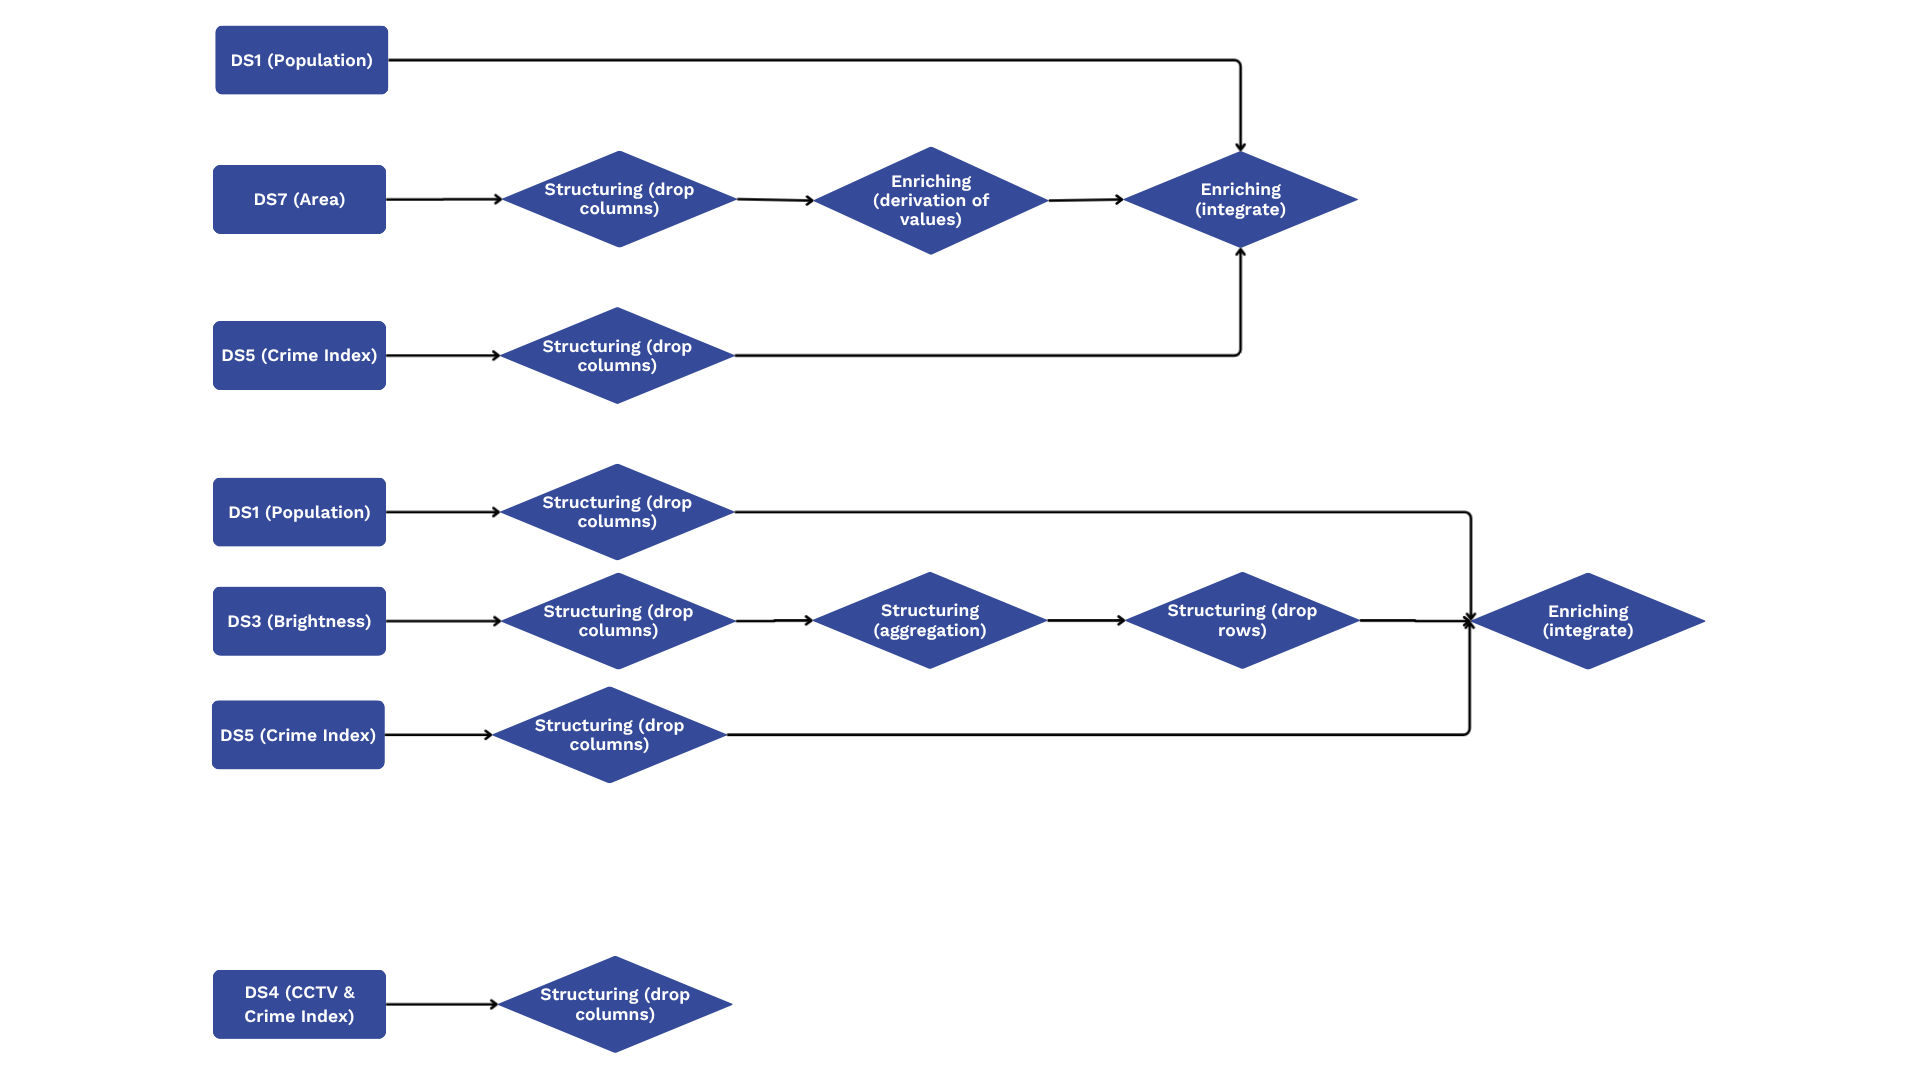

We will first rename our datasets so that the steps in our processing stage are clearer and easier to follow.

In [34]:
df1_proc = df1.copy()
print(df1_proc.head())
print(df1_proc.info())

      city        lat         lng      country  population
0    Tokyo  35.689701  139.692200        Japan  37977000.0
1  Jakarta  -6.214600  106.845100    Indonesia  34540000.0
2    Delhi  28.660000   77.230003        India  29617000.0
3   Mumbai  18.966700   72.833298        India  23355000.0
4   Manila  14.595800  120.977203  Philippines  23088000.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7170 entries, 0 to 7169
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   city        7170 non-null   object 
 1   lat         7170 non-null   float32
 2   lng         7170 non-null   float32
 3   country     7170 non-null   object 
 4   population  7170 non-null   float32
dtypes: float32(3), object(2)
memory usage: 196.2+ KB
None


In [35]:
df3_proc = df_brightness.copy()
print(df3_proc.head())
print(df3_proc.tail())
print(df3_proc.info())


    Latitude  Longitude  Country  LimitingMag Clean_Country
0  45.494347  15.533149  Croatia          2.0       Croatia
1  45.499866  15.525713  Croatia          2.0       Croatia
2  45.486893  15.538268  Croatia          2.0       Croatia
3  45.513187  15.521187  Croatia          3.0       Croatia
4  45.495689  15.467396  Croatia          6.0       Croatia
        Latitude   Longitude                        Country  LimitingMag  \
14368   5.795222  100.897430                       Malaysia          0.0   
14369  42.316822  -71.287743  United States - Massachusetts          0.0   
14370  40.439583  -79.989319   United States - Pennsylvania          1.0   
14371  33.989700   35.320202                        Jamaica          7.0   
14372 -43.626999  171.656006                    New Zealand          4.0   

       Clean_Country  
14368       Malaysia  
14369  United States  
14370  United States  
14371        Jamaica  
14372    New Zealand  
<class 'pandas.core.frame.DataFrame'>
RangeIn

### Structuring data from DS7

Since DS7 is a very large dataset, it results in very high RAM usage. We will first perform attribute-based filtering on DS7 such that only relevant columns are kept, especially since DS7 is a very large dataset. In the code below, we will remove all unnecessary variables not needed for area calculation of specific cities, which will also help to lower the RAM usage of our code.

Required info | Your answer
-------------------|------------------
GenAI tool name | ChatGPT
Input prompt | The RAM usage after the identification and analysis of DS7 source is very high. Help me to reduce the RAM by removing all unnecessary variables and only keep attributes "city", "country" and "geometry"
Generated output |see comments in Structuring data from DS7 - code cell 1


In [36]:
#prompt: The RAM usage after the identification and analysis of DS7 source is very high. Help me to reduce the RAM by removing all unnecessary variables and only keep attributes "city", "country" and "geometry"


# Delete temporary variables that are no longer needed for the next stage of analysis
for var in [
    "temp",
    "dup_keys",
    "dup_geom",
    "geom_check",
    "linked_cities",
    "ds7_unique_cities",
    "continents_cleaned",
    "merged_ds7_continents",
    "continent_country_counts",
    "unmatched_countries"
]:
    if var in globals():
        del globals()[var]

# Keep only the COUNTRY, CITY, and geometry columns, and remove rows with missing values
gdf = gdf[["COUNTRY", "CITY", "geometry"]].dropna(subset=["COUNTRY", "CITY", "geometry"]).copy()

# Standardize COUNTRY names by converting to string and stripping whitespace
gdf["COUNTRY"] = gdf["COUNTRY"].astype(str).str.strip()

# Standardize CITY names by converting to string and stripping whitespace
gdf["CITY"] = gdf["CITY"].astype(str).str.strip()

# Remove rows where COUNTRY or CITY is blank after cleaning
gdf = gdf[(gdf["COUNTRY"] != "") & (gdf["CITY"] != "")].copy()

# Run garbage collection to free memory from deleted objects
gc.collect()

27589

###Enriching by new attribute "area_km2" in DS7 through derivation of values

As mentioned in the identification stage for DS7, we noted that there are multiple geometry values of the same area. In the GADM dataset, administrative units may be represented as multipart geometries consisting of disconnected components (e.g., islands or exclaves). When these components belong to the same city, they should be merged into a single geometry to accurately represent the city’s full spatial extent. The total area can then be computed from this unified geometry. Derivation of values are obtain using standard GIS area computation methods as shown in the code below.


Required info | Your answer
-------------------|------------------
GenAI tool name | ChatGPT
Input prompt | Using standard GIS area computation, help me generate the area in km2 using the geometry values. Please clean the data, remove missing and blank values, process one country at a time to reduce memory usage, remove exact duplicate geometries within the same city, union all geometry pieces for each "COUNTRY" and "CITY", compute the merged area in km², save the result as final_city_area, and print the first 5 rows.
Generated output |see comments in Structuring data from DS7 - code cell 2


In [37]:
#prompt: Using standard GIS area computation, help me generate the area in km2 using the geometry values. Please clean the data, remove missing and blank values, process one country at a time to reduce memory usage, remove exact duplicate geometries within the same city, union all geometry pieces for each "COUNTRY" and "CITY", compute the merged area in km², save the result as final_city_area, and print the first 5 rows.

# Keep only the COUNTRY, CITY, and geometry columns, and remove rows with missing values
gdf = gdf[["COUNTRY", "CITY", "geometry"]].dropna(subset=["COUNTRY", "CITY", "geometry"]).copy()

# Standardize COUNTRY names by converting to string and stripping whitespace
gdf["COUNTRY"] = gdf["COUNTRY"].astype(str).str.strip()

# Standardize CITY names by converting to string and stripping whitespace
gdf["CITY"] = gdf["CITY"].astype(str).str.strip()

# Remove rows where COUNTRY or CITY is blank after cleaning
gdf = gdf[(gdf["COUNTRY"] != "") & (gdf["CITY"] != "")].copy()

# Initialize a geodetic calculator using the WGS84 ellipsoid for area computation
geod = Geod(ellps="WGS84")

# Define a function to calculate geometry area in square kilometers
def area_km2_from_geom(geom):
    if geom is None or geom.is_empty:
        return None
    area_m2, _ = geod.geometry_area_perimeter(geom)
    return abs(area_m2) / 1_000_000

# Create an empty list to store the processed results for each country
results = []

# Process the dataset one country at a time to reduce memory usage
for country, country_df in gdf.groupby("COUNTRY", sort=False):
    # Keep only CITY and geometry columns for the current country
    country_df = country_df[["CITY", "geometry"]].copy()

    # Convert geometry to WKB format so exact duplicate geometries can be identified
    country_df["geometry_wkb"] = country_df["geometry"].apply(lambda x: x.wkb)

    # Remove duplicate CITY-geometry pairs within the current country
    country_df = country_df.drop_duplicates(subset=["CITY", "geometry_wkb"]).drop(columns="geometry_wkb")

    # Merge all geometry pieces belonging to the same city into one final geometry
    merged = (
        country_df.groupby("CITY", sort=False)["geometry"]
        .agg(lambda s: s.iloc[0] if len(s) == 1 else unary_union(list(s)))
        .reset_index()
    )

    # Calculate the final area in km² for each merged city geometry
    merged["area_km2"] = merged["geometry"].apply(area_km2_from_geom)

    # Add the current country name back to the merged result
    merged["COUNTRY"] = country

    # Store only the final COUNTRY, CITY, and area_km2 columns
    results.append(merged[["COUNTRY", "CITY", "area_km2"]])

    # Delete temporary objects for the current country and free memory
    del country_df, merged
    gc.collect()

# Combine all country-level results into one final table
final_city_area = pd.concat(results, ignore_index=True)

# Delete the results list and free memory
del results
gc.collect()

# Display the first 5 rows of the final city-area table
print(final_city_area.head())

       COUNTRY       CITY     area_km2
0  Afghanistan    Baharak  3003.880346
1  Afghanistan     Darwaz  2920.786853
2  Afghanistan   Fayzabad  2940.052009
3  Afghanistan  Ishkashim  1569.734355
4  Afghanistan       Jurm  3510.888507


###Enriching data by integration of DS1 and DS7

Now with the derived area for each specific country, we will proceed to conduct an inner join for these values with DS1 for the corresponding 2816 matched cities. This will give us a new table with merged values from DS1 dataset table and final DS7 table. This is done by ensuring the columns of "COUNTRY" and "CITY" in the final DS7 table are standardised to "country" and "city" for a successful join with DS1.

In [38]:
# Make a clean copy of the final DS7 city-area table
ds7_final = final_city_area.copy()

# Standardize DS7 column names to match DS1
ds7_final = ds7_final.rename(columns={
    "COUNTRY": "country",
    "CITY": "city"
})

# Clean text in both datasets
df1_proc["country"] = df1_proc["country"].astype(str).str.strip()
df1_proc["city"] = df1_proc["city"].astype(str).str.strip()

ds7_final["country"] = ds7_final["country"].astype(str).str.strip()
ds7_final["city"] = ds7_final["city"].astype(str).str.strip()


# Inner join: keep only matched city-country pairs
ds1_ds7_joined = pd.merge(
    df1_proc,
    ds7_final,
    on=["city", "country"],
    how="inner"
)

print("Number of rows in final joined table:", len(ds1_ds7_joined))
print(ds1_ds7_joined.head())

Number of rows in final joined table: 2816
        city        lat         lng      country  population      area_km2
0     Manila  14.595800  120.977203  Philippines  23088000.0     36.671323
1   Shanghai  31.166700  121.466698        China  22120000.0   6883.762529
2  São Paulo -23.550400  -46.633900       Brazil  22046000.0   1521.201503
3  Guangzhou  23.128799  113.259003        China  20902000.0   7135.803880
4    Beijing  39.904999  116.391403        China  19433000.0  16405.407350


As seen from the results, there are exactly 2816 merged rows. This corresponds to our previous findings in the identification step. With the correct population and area data, we can now proceed to calculate our population density for these 2816 cities.

In [39]:
ds1_ds7_joined["population_density"] = ds1_ds7_joined["population"] / ds1_ds7_joined["area_km2"]

print(ds1_ds7_joined.head())

        city        lat         lng      country  population      area_km2  \
0     Manila  14.595800  120.977203  Philippines  23088000.0     36.671323   
1   Shanghai  31.166700  121.466698        China  22120000.0   6883.762529   
2  São Paulo -23.550400  -46.633900       Brazil  22046000.0   1521.201503   
3  Guangzhou  23.128799  113.259003        China  20902000.0   7135.803880   
4    Beijing  39.904999  116.391403        China  19433000.0  16405.407350   

   population_density  
0       629592.782623  
1         3213.358960  
2        14492.491597  
3         2929.172431  
4         1184.548459  


###Enriching data from DS1 and DS3 through integration

We will join the two datasets such that our final dataframe will consist of the city, country and LimitingMag.

We have observed in the identification step that there are multiple LimitingMag (brightness) records for a single city in DS3, thus we will use aggregation to get the mean value of all the recorded brightness levels in the city so that each city record will only have one corresponding LimitingMag value.

We first perform a fuzzy left outer join based on the longitude and latitude data of the two datasets and also aggregate all the LimitingMag data for each city, using the mean of all the LimitingMag data for that city. We will also perform record-based filtering so that rows with null values for the LimitingMag attribute are removed.

Required info | Your answer
-------------------|------------------
GenAI tool name | ChatGPT
Input prompt | perform a left outer join using the "lat" and "lng" attributes of df1_proc (left) against the "Latitude" and "Longitude" attributes of df3_proc (right) respectively. if both the "lat" and "Latitiude" are within 0.1 degrees of each other and the "lng" and "Longitude" are within 0.1 degrees of each other, consider them to be the same. then take the mean of all the LimitingMag values for the records which have the same "city" value and put the results into a new dataframe. the new dataframe does not need to have longitude and latitude, only "city", "country", "LimitingMag". if the final value of LimitingMag is NaN, then delete the row from the dataframe entirely, then print the final dataframe without any NaN values
Generated output |see comments in Structuring data from DS1 and DS3 - code cell 1


In [40]:
#prompt: perform a left outer join using the "lat" and "lng" attributes of df1_proc (left) against the "Latitude" and "Longitude" attributes of df3_proc (right) respectively. if both the "lat" and "Latitiude" are within 0.1 degrees of each other and the "lng" and "Longitude" are within 0.1 degrees of each other, consider them to be the same. then take the mean of all the LimitingMag values for the records which have the same "city" value and put the results into a new dataframe. the new dataframe does not need to have longitude and latitude, only "city", "country", "LimitingMag". if the final value of LimitingMag is NaN, then delete the row from the dataframe entirely, then print the final dataframe without any NaN values

# Cities dataframe
df_cities = df1_proc[['city', 'country', 'lat', 'lng']].copy()

# Brightness dataframe
df_brightness = df3_proc[['Latitude', 'Longitude', 'LimitingMag']].copy()

# Convert to numpy arrays for KD-Tree
city_coords = df_cities[['lat', 'lng']].to_numpy()
brightness_coords = df_brightness[['Latitude', 'Longitude']].to_numpy()

# Build KD-Tree
tree = cKDTree(brightness_coords)

# Define the tolerance for matching (in degrees)
tolerance = 0.1

# Query nearest neighbors within tolerance
indices_list = tree.query_ball_point(city_coords, r=tolerance)

# Map matched brightness values
matched_brightness = []
for city_idx, brightness_indices in enumerate(indices_list):
    if brightness_indices:  # if any matches
        mean_brightness = df_brightness.iloc[brightness_indices]['LimitingMag'].mean()
    else:
        mean_brightness = np.nan  # no match
    matched_brightness.append(mean_brightness)

# Add results to cities dataframe
df_cities['LimitingMag'] = matched_brightness

# Drop longitude and latitude attributes
df_final = df_cities.drop(columns=['lat', 'lng'])

# Drop rows where LimitingMag is NaN
df_final = df_final.dropna(subset=['LimitingMag']).reset_index(drop=True)

# Inspect results
print("Merged Brightness DataFrame without NaNs (head):")
print(df_final.head())
print("\nMerged Brightness DataFrame info:")
df_final.info()

Merged Brightness DataFrame without NaNs (head):
          city country  LimitingMag
0        Tokyo   Japan     1.230769
1        Delhi   India     0.000000
2       Mumbai   India     0.000000
3    São Paulo  Brazil     4.666667
4  Mexico City  Mexico     1.000000

Merged Brightness DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 974 entries, 0 to 973
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   city         974 non-null    object 
 1   country      974 non-null    object 
 2   LimitingMag  974 non-null    float64
dtypes: float64(1), object(2)
memory usage: 23.0+ KB


We then rename the attribute "LimitingMag" to "avg_LimitingMag" for clarity

In [41]:
# Rename LimitingMag to avg_LimitingMag
df_final = df_final.rename(columns={'LimitingMag': 'avg_LimitingMag'})

# Inspect results
print(df_final.head(), "\n")
df_final.info()

          city country  avg_LimitingMag
0        Tokyo   Japan         1.230769
1        Delhi   India         0.000000
2       Mumbai   India         0.000000
3    São Paulo  Brazil         4.666667
4  Mexico City  Mexico         1.000000 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 974 entries, 0 to 973
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   city             974 non-null    object 
 1   country          974 non-null    object 
 2   avg_LimitingMag  974 non-null    float64
dtypes: float64(1), object(2)
memory usage: 23.0+ KB


### Structuring data from DS4 and DS5




**Dropping irrelevant columns from CCTV & Crime.csv**

Some of the columns provided in the original file are irrelevant for our application. We thus perform attribute-based filtering to remove these columns.

In [42]:
# Read the file again to start data processing
df4_proc = pd.read_csv('/content/drive/MyDrive/SC3021/DS4 Cities with CCTV & Crime Index.csv')

# Drop irrelevant columns
df4_proc = df4_proc.drop(columns=['# of CCTV Cameras', '# of People'])
df4_proc = df4_proc.drop(columns=['# of CCTV Cameras per 1,000 People'])

print(df4_proc.head())
print(df4_proc.info())

       City       Country  Cameras per Square Mile  Crime Index
0   Taiyuan         China                   174.39        34.31
1      Wuxi         China                   472.66         7.84
2    London  England (UK)                  1138.48        53.07
3    Indore         India                   133.29        49.88
4  Changsha         China                   353.85        21.38
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   City                     134 non-null    object 
 1   Country                  134 non-null    object 
 2   Cameras per Square Mile  131 non-null    float64
 3   Crime Index              129 non-null    float64
dtypes: float64(2), object(2)
memory usage: 4.3+ KB
None


**Dropping irrelevant columns from World Crime Index.csv**

Similarly, we remove all irrelevant attributes from the crime index dataset.

In [43]:
# Read file again to start data procession
df5_proc = pd.read_csv('/content/drive/MyDrive/SC3021/DS5 World Crime Index.csv')

# Drop irrelevant columns
df5_proc = df5_proc.drop(columns = ['Safety Index', 'Rank'])

print(df5_proc.head())
print(df5_proc.info())

           City            Country  Crime Index
0       Caracas          Venezuela         83.6
1      Pretoria       South Africa         82.0
2        Durban       South Africa         81.0
3  Port Moresby   Papua New Guinea         80.7
4  Johannesburg       South Africa         80.7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416 entries, 0 to 415
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   City         416 non-null    object 
 1   Country      416 non-null    object 
 2   Crime Index  416 non-null    float64
dtypes: float64(1), object(2)
memory usage: 9.9+ KB
None


### Enriching crime index data from DS4 and DS5 through integration


We now proceed to perform a left outer join between DS4 and DS5 on the columns "city" and "country". To maximise matching potential, we apply case-insensitive normalisation (lowercase and strip whitespace) to both datasets before joining, consistent with the approach used when building the three analytical datasets. To prevent confusion, we will rename the crime index from DS4 to Crime Index_cctv and crime index from DS5 to Crime Index_crime.

In [44]:
# Rename columns for consistent merging
df4_proc_renamed = df4_proc.rename(columns={'City': 'city', 'Country': 'country'})
df5_proc_renamed = df5_proc.rename(columns={'City': 'city', 'Country': 'country'})

# Apply case-insensitive normalisation (lowercase + strip) on copies for matching
df4_for_merge = df4_proc_renamed.copy()
df4_for_merge['city']    = df4_for_merge['city'].str.lower().str.strip()
df4_for_merge['country'] = df4_for_merge['country'].str.lower().str.strip()

df5_for_merge = df5_proc_renamed.copy()
df5_for_merge['city']    = df5_for_merge['city'].str.lower().str.strip()
df5_for_merge['country'] = df5_for_merge['country'].str.lower().str.strip()

# Left outer join on normalised city and country
merged_df_cctv_crime = pd.merge(df4_for_merge, df5_for_merge, on=['city', 'country'], how='left', suffixes=('_cctv', '_crime'))

print("Merged DataFrame after left outer join (normalised, case-insensitive):")
print(merged_df_cctv_crime.head())
print(merged_df_cctv_crime.tail())

Merged DataFrame after left outer join (normalised, case-insensitive):
       city       country  Cameras per Square Mile  Crime Index_cctv  \
0   taiyuan         china                   174.39             34.31   
1      wuxi         china                   472.66              7.84   
2    london  england (uk)                  1138.48             53.07   
3    indore         india                   133.29             49.88   
4  changsha         china                   353.85             21.38   

   Crime Index_crime  
0                NaN  
1                NaN  
2                NaN  
3               48.8  
4                NaN  
       city       country  Cameras per Square Mile  Crime Index_cctv  \
130  riyadh  saudi arabia                     0.22             26.99   
131   abuja       nigeria                     0.01             59.57   
132  bekasi     indonesia                     0.35             35.85   
133  ibadan       nigeria                     0.00             50.08  

After the left outer join is performed, we observe that many rows still have null values for the Crime Index_crime attribute from DS5. We conduct further investigation by filtering for rows where the Crime Index_crime attribute is not null, to quantify how many cities successfully matched.

We used Python's built-in `sqlite3` library. The SQL query uses `LOWER(TRIM())` for case-insensitive matching, consistent with the pandas approach above, and additionally runs an INNER JOIN to report the exact number of cities that matched across both datasets.

In [45]:


# Load both DataFrames into an in-memory SQLite database
conn = sqlite3.connect(':memory:')
df4_proc_renamed.to_sql('ds4', conn, index=False, if_exists='replace')
df5_proc_renamed.to_sql('ds5', conn, index=False, if_exists='replace')

# SQL LEFT OUTER JOIN on city and country (case-insensitive)
sql_join = """
    SELECT
        d4.city,
        d4.country,
        d4."Cameras per Square Mile",
        d4."Crime Index"  AS "Crime Index_cctv",
        d5."Crime Index"  AS "Crime Index_crime"
    FROM ds4 d4
    LEFT OUTER JOIN ds5 d5
        ON LOWER(TRIM(d4.city))    = LOWER(TRIM(d5.city))
        AND LOWER(TRIM(d4.country)) = LOWER(TRIM(d5.country))
"""
merged_sql = pd.read_sql_query(sql_join, conn)
print("SQL LEFT OUTER JOIN — first 5 rows:")
print(merged_sql.head())

# Check: how many rows have a matched Crime Index from DS5?
sql_check = """
    SELECT COUNT(*) AS matched_rows
    FROM ds4 d4
    INNER JOIN ds5 d5
        ON LOWER(TRIM(d4.city))    = LOWER(TRIM(d5.city))
        AND LOWER(TRIM(d4.country)) = LOWER(TRIM(d5.country))
"""
result = pd.read_sql_query(sql_check, conn)
print(f"\nSQL INNER JOIN matched rows: {result['matched_rows'].iloc[0]}")
conn.close()

SQL LEFT OUTER JOIN — first 5 rows:
       city       country  Cameras per Square Mile  Crime Index_cctv  \
0   Taiyuan         China                   174.39             34.31   
1      Wuxi         China                   472.66              7.84   
2    London  England (UK)                  1138.48             53.07   
3    Indore         India                   133.29             49.88   
4  Changsha         China                   353.85             21.38   

   Crime Index_crime  
0                NaN  
1                NaN  
2                NaN  
3               48.8  
4                NaN  

SQL INNER JOIN matched rows: 72





With case-insensitive normalisation, DS4 and DS5 share 72 cities. However, we still treat the 2 datasets independently for the following reasons:

- **Sample loss:** 72 matched cities represent only a subset of DS4's full coverage. Restricting this merged dataset  to these 72 cities would discard a significant portion of the CCTV data, which is around 40%.
- **Internal consistency:** DS4 already contains its own Crime Index from the same source as the camera counts. Using this built-in Crime Index ensures the two variables in the merged dataset come from a consistent data collection effort.

We therefore retain DS4's full dataset with its own Crime Index for the CCTV analysis, giving us three separate analytical datasets.

### Enriching crime index data to form final datasets through integration

The three separate analytical datasets will be as follows:
1) Dataset A - Population Density on Crime Index (DS1 and DS5)
2) Dataset B - Light intensity at night on Crime Index (DS3 and DS5)
3) Dataset C - CCTV Number on Crime INdex (DS4)

In [46]:
# Normalise city and country names before joining to handle naming inconsistencies across datasets
def normalise(series):
    return series.astype(str).str.strip().str.lower()

# Dataset A: Population Density vs Crime Index (DS1 + DS7 joined with DS5)
ds1_ds7_norm = ds1_ds7_joined[['city', 'country', 'population_density']].copy()
ds1_ds7_norm['city']    = normalise(ds1_ds7_norm['city'])
ds1_ds7_norm['country'] = normalise(ds1_ds7_norm['country'])

df5_norm = df5_proc_renamed.copy()
df5_norm['city']    = normalise(df5_norm['city'])
df5_norm['country'] = normalise(df5_norm['country'])

dataset_A = pd.merge(
    ds1_ds7_norm,
    df5_norm[['city', 'country', 'Crime Index']],
    on=['city', 'country'],
    how='inner'
).dropna().reset_index(drop=True)

# Dataset B: Night Brightness vs Crime Index (DS1 + DS3 joined with DS5)
df_final_norm = df_final[['city', 'country', 'avg_LimitingMag']].copy()
df_final_norm['city']    = normalise(df_final_norm['city'])
df_final_norm['country'] = normalise(df_final_norm['country'])

dataset_B = pd.merge(
    df_final_norm,
    df5_norm[['city', 'country', 'Crime Index']],
    on=['city', 'country'],
    how='inner'
).dropna().reset_index(drop=True)

# Dataset C: CCTV Density vs Crime Index (DS4 directly — already contains both columns)
dataset_C = df4_proc_renamed[['city', 'country', 'Cameras per Square Mile', 'Crime Index']].dropna().reset_index(drop=True)

print(f'Dataset A (Population Density): {len(dataset_A)} cities')
print(f'Dataset B (Night Brightness):   {len(dataset_B)} cities')
print(f'Dataset C (CCTV Density):        {len(dataset_C)} cities')
print()
print('Dataset A sample:'); print(dataset_A.head())
print('Dataset B sample:'); print(dataset_B.head())
print('Dataset C sample:'); print(dataset_C.head())

Dataset A (Population Density): 133 cities
Dataset B (Night Brightness):   94 cities
Dataset C (CCTV Density):        126 cities

Dataset A sample:
        city      country  population_density  Crime Index
0     manila  philippines       629592.782623         65.4
1   shanghai        china         3213.358960         30.6
2  guangzhou        china         2929.172431         32.3
3    beijing        china         1184.548459         28.4
4   shenzhen        china         8310.601076         28.9
Dataset B sample:
          city country  avg_LimitingMag  Crime Index
0        tokyo   japan         1.230769         24.6
1        delhi   india         0.000000         59.2
2       mumbai   india         0.000000         45.0
3  mexico city  mexico         1.000000         68.5
4        cairo   egypt         2.000000         50.0
Dataset C sample:
       city       country  Cameras per Square Mile  Crime Index
0   Taiyuan         China                   174.39        34.31
1      Wuxi     

Each dataset is self-contained with a single urban development factor and the corresponding Crime Index, enabling independent regression analysis per factor. Dataset A and B draw Crime Index values from DS5, while Dataset C uses the Crime Index already present in DS4. Standardisation of variables will be performed in the analysis stage prior to regression to allow comparison of beta coefficients across the three models.

## Data Analysis

Given that our overarching goal is to determine if there is a relationship between each of the urban developmental factors and crime index, we apply the use of the following methods from descriptive / predictive analytics:

*   Visualization (Descriptive analysis)
*   Relationship and dependency analysis (Diagnostic analysis)
*   Regression Analysis (Diagnostic analysis)


### Visualization


**Goal:** The goal is to visually describe the distribution of each urban developmental factors for the different crime indices. This will serve as an exploratory step so that we will be able to choose analytical methods that are more suited to the datasets when conducting regression.

**Methods / measures:** We use scatter plots to allow us to better conduct trend analysis.

**Code:** For each urban developmental factor and the corresponding crime index data, we generate a scatter plot.


Required info | Your answer
-------------------|------------------
GenAI tool name | Claude AI
Input prompt | Generate code to create 3 side by side scatter plots showing the relationship between population density, night brightness and CCTV density using Crime index using dataset_A, dataset_B and dataset_C
Generated output |see comments under Data analysis(Visualization) - code cell 1


Text(0.5, 1.0, 'CCTV Density vs Crime Index')

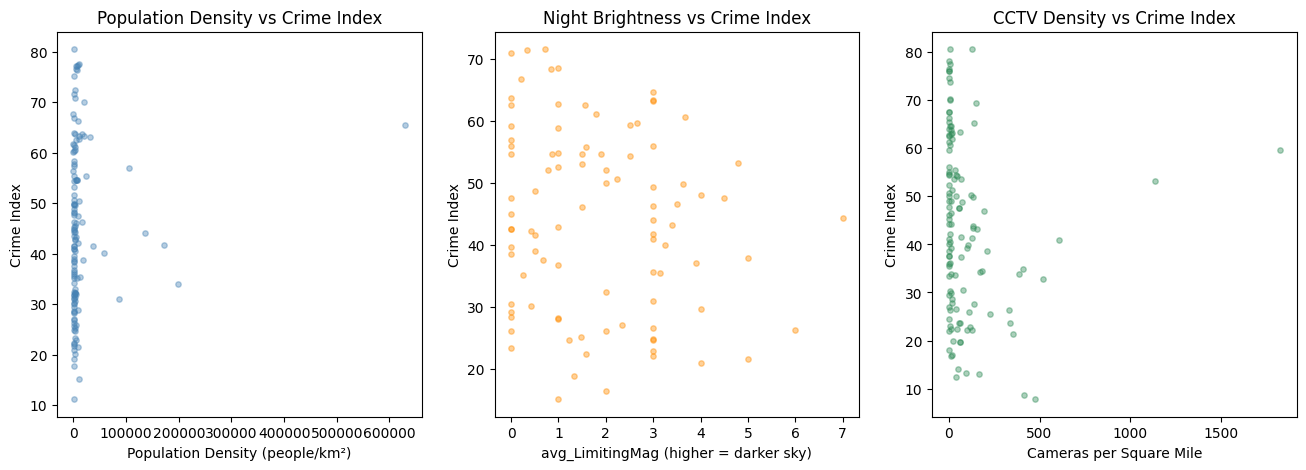

In [47]:
#prompt: Generate code to create 3 side by side scatter plots showing the relationship between population density, night brightness and CCTV density using Crime index using dataset_A, dataset_B and dataset_C
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Scatter plot of population density vs crime index (Dataset A)
axes[0].scatter(dataset_A['population_density'], dataset_A['Crime Index'], alpha=0.4, s=15, color='steelblue')
axes[0].set_xlabel('Population Density (people/km²)')
axes[0].set_ylabel('Crime Index')
axes[0].set_title('Population Density vs Crime Index')

# Plot 2: Scatter plot of night brightness vs crime index (Dataset B)
axes[1].scatter(dataset_B['avg_LimitingMag'], dataset_B['Crime Index'], alpha=0.4, s=15, color='darkorange')
axes[1].set_xlabel('avg_LimitingMag (higher = darker sky)')
axes[1].set_ylabel('Crime Index')
axes[1].set_title('Night Brightness vs Crime Index')

# Plot 3: Scatter plot of CCTV density vs crime index (Dataset C)
axes[2].scatter(dataset_C['Cameras per Square Mile'], dataset_C['Crime Index'], alpha=0.4, s=15, color='seagreen')
axes[2].set_xlabel('Cameras per Square Mile')
axes[2].set_ylabel('Crime Index')
axes[2].set_title('CCTV Density vs Crime Index')

**Interpretation.** We observe significantly more data points on the left of our scatter plots compared to the right, making our datasets heavily right-skewed. Furthermore, there are many 0 values for LimitingMag, which gives rise to the floor effect. There is no immediately obvious trend just by looking at the scatter plots visually, so further analysis (see regression analysis below) will be required to draw a general conclusion based on our data sample.


**Limitations.** We are aware that our datasets are biased in the sense that the data collected is not evenly spread across the different regions, and there are certain regions that are overrepresented or underrepresented in our datasets, which we will have to keep in mind when conducting further analysis.

### Relationship and dependency analysis

**Goal:**
The goal is to identify if there is a relationship between each urban developmental factor and crime index.

**Methods / measures:**
We apply a correlation analysis. Spearman is used instead of Pearson as it is rank-based and does not assume linearity, making it more appropriate for our data given the skewed population density distribution and the floor effect in LimitingMag.

**Code:** The following code computes the Spearman correlation between each of the urban developmental factors and the crime index.

Required info | Your answer
-------------------|------------------
GenAI tool name | Claude AI
Input prompt | Generate code to find the spearman correlation (including rho, p-value, and sample size (n)) between population density, night brightness and cctv density with crime index using dataset A, B and C.
Generated output |see comments under Data analysis(Visualization) - code cell 2


In [48]:
# Compute Spearman correlation between each factor and Crime Index
corr_A, p_A = stats.spearmanr(dataset_A['population_density'], dataset_A['Crime Index'])
corr_B, p_B = stats.spearmanr(dataset_B['avg_LimitingMag'], dataset_B['Crime Index'])
corr_C, p_C = stats.spearmanr(dataset_C['Cameras per Square Mile'], dataset_C['Crime Index'])

# Print the correlation results including rho, p-value, and sample size (n) for each dataset
print(f"Population Density vs Crime Index : rho = {corr_A:.3f}, p = {p_A:.4f}  (n={len(dataset_A)})")
print(f"Night Brightness vs Crime Index   : rho = {corr_B:.3f}, p = {p_B:.4f}  (n={len(dataset_B)})")
print(f"CCTV Density vs Crime Index        : rho = {corr_C:.3f}, p = {p_C:.4f}  (n={len(dataset_C)})")

Population Density vs Crime Index : rho = 0.150, p = 0.0851  (n=133)
Night Brightness vs Crime Index   : rho = -0.162, p = 0.1190  (n=94)
CCTV Density vs Crime Index        : rho = -0.349, p = 0.0001  (n=126)


**Interpretation.** Based on this initial exploratory analysis, we notice that for both population density and brightness, there is no strong evidence of monotonic relationships due to the small rank correlation and the p-value being greater than 0.05.
However, for CCTV density, there seems to be evidence of a statistically significant negative monotonic relationship, since it has a relatively larger rank correlation coefficient and a p-value that is smaller than 0.05.

**Limitations.** Spearman correlation only detects monotonic relationships, so if the true relationship between a factor and crime index is non-linear and non-monotonic (e.g. U-shaped), it would not be captured here. Additionally, the relatively small sample sizes, particularly for Dataset B and Dataset C, limit the statistical power of the analysis. To better identify underlying relationships, we apply data quality fixes before conducting regression in the following section.

### Regression Analysis

### Data quality fixes before regression analysis



Based on the observations above — right-skewness in population density and CCTV density, and a floor effect in night brightness — we apply the following fixes to the data before regression.

**Fix 1 — Winsorizing for Dataset A (Population Density):** Population density is heavily right-skewed. Rather than removing outliers entirely, we apply winsorizing — capping values at Q3 + 1.5×IQR. This retains all cities while reducing the influence of extreme values such as Manila.

**Fix 2 — Zero LimitingMag in Dataset B (Night Brightness):** 18 out of 94 cities have avg_LimitingMag = 0, representing maximum light pollution (a floor effect in the Globe at Night sensor data). These are plausible readings for dense megacities such as Delhi, Mumbai, and Paris. These zero values are retained as valid data points and handled by the rank-based Spearman correlation used in the relationship analysis above.

**Fix 3 — Zero camera cities removed from Dataset C (CCTV):** 2 cities with 0 cameras per square mile are removed before log transformation as log(0) is undefined.

### Data quality fix -- Wizorising
Winsorizing for Dataset A (Population Density): Population density is heavily right-skewed. Rather than removing outliers entirely, we apply winsorizing — capping values at Q3 + 1.5×IQR. This retains all cities while reducing the influence of extreme values such as Manila.

Required info | Your answer
-------------------|------------------
GenAI tool name | Claude AI
Input prompt | generate code to cap outliers in dataset_A population density using IQR, count and report zero avg_LimitingMag in dataset_B, and remove rows with zero CCTV density in dataset_C.
Generated output |see comments under Data analysis(Visualization) - code cell 3


In [49]:
#prompt: generate code to cap outliers in dataset_A population density using IQR, count and report zero avg_LimitingMag in dataset_B, and remove rows with zero CCTV density in dataset_C.
# Fix 1: Winsorize Dataset A (cap extreme population density values)
Q1 = dataset_A['population_density'].quantile(0.25)
Q3 = dataset_A['population_density'].quantile(0.75)
IQR = Q3 - Q1
cap = Q3 + 1.5 * IQR
dataset_A['population_density'] = dataset_A['population_density'].clip(upper=cap)
print(f'Dataset A: population density capped at {cap:,.1f} (Q3 + 1.5×IQR)')
print(f'Cities retained: {len(dataset_A)} (all cities kept)')

# Fix 2: Document zero LimitingMag cities in Dataset B — retain as genuine readings
zero_count = (dataset_B['avg_LimitingMag'] == 0).sum()
print(f'\nDataset B: {zero_count}/{len(dataset_B)} cities have avg_LimitingMag = 0 — retained as floor effect.')

# Fix 3: Remove cities with 0 cameras per square mile from Dataset C (log(0) is undefined)
before_c = len(dataset_C)
dataset_C = dataset_C[dataset_C['Cameras per Square Mile'] > 0].reset_index(drop=True)
print(f'\nDataset C: {before_c} → {len(dataset_C)} cities after removing {before_c - len(dataset_C)} cities with 0 cameras.')

Dataset A: population density capped at 12,389.2 (Q3 + 1.5×IQR)
Cities retained: 133 (all cities kept)

Dataset B: 18/94 cities have avg_LimitingMag = 0 — retained as floor effect.

Dataset C: 126 → 124 cities after removing 2 cities with 0 cameras.


### Data quality fix — Log transformation

CCTV cameras per square mile (Dataset C) is right-skewed, so we apply a log transformation to reduce skewness. After removing 2 cities with 0 cameras (where log is undefined), we apply log to the remaining values.

Population density (Dataset A) is not log-transformed. Log transformation was initially applied to reduce skewness, but produced a weaker and non-significant result (β = 0.051, p = 0.589) compared to the linear model (β = 0.216, p = 0.019), indicating the linear specification better captures the relationship between population density and crime index. The log transform was therefore reverted for Dataset A.

Night brightness (Dataset B) is also left untransformed as its scale is already bounded [0–7].

Required info | Your answer
-------------------|------------------
GenAI tool name | Claude AI
Input prompt | generate code to apply a log transformation to CCTV density in dataset_C, drop the original column, and print summary ranges while keeping dataset_A unchanged.
Generated output |see comments under Data analysis(Visualization) - code cell 4


In [50]:
#prompt: generate code to apply a log transformation to CCTV density in dataset_C, drop the original column, and print summary ranges while keeping dataset_A unchanged.

# Log transform CCTV cameras per square mile (Dataset C) only
dataset_C['log_cameras_per_sq_mile'] = np.log(dataset_C['Cameras per Square Mile'])
dataset_C = dataset_C.drop(columns=['Cameras per Square Mile'])

print('Log transformation applied to Dataset C only.')
print(f"Dataset C — log_cameras_per_sq_mile range: {dataset_C['log_cameras_per_sq_mile'].min():.2f} to {dataset_C['log_cameras_per_sq_mile'].max():.2f}")
print(f"Dataset A — population_density (winsorized, no log): {dataset_A['population_density'].min():.1f} to {dataset_A['population_density'].max():.1f}")

Log transformation applied to Dataset C only.
Dataset C — log_cameras_per_sq_mile range: -4.61 to 7.51
Dataset A — population_density (winsorized, no log): 2.1 to 12389.2


### Data quality fix — Standardise variables

To allow direct comparison of regression coefficients across the three models, we standardise (z-score) both the predictor and Crime Index in each dataset. After standardisation, a coefficient of 1.0 means a one standard deviation increase in the factor is associated with a one standard deviation increase in Crime Index.

Required info | Your answer
-------------------|------------------
GenAI tool name | Claude AI
Input prompt | generate code to define a z-score standardisation function and apply it to population density and crime index in dataset_A, avg_LimitingMag and crime index in dataset_B, and log CCTV density and crime index in dataset_C, storing results in new datasets and printing their means and standard deviations to verify standardisation.
Generated output |see comments under Data analysis(Visualization) - code cell 5


In [51]:
#prompt: generate code to define a z-score standardisation function and apply it to population density and crime index in dataset_A, avg_LimitingMag and crime index in dataset_B, and log CCTV density and crime index in dataset_C, storing results in new datasets and printing their means and standard deviations to verify standardisation.
# Define a function to standardise a series using z-score (mean = 0, std = 1)
def z_score(series):
    return (series - series.mean()) / series.std()

# Apply standardisation to Dataset A (population density and crime index)
dataset_A_std = dataset_A.copy()
dataset_A_std['population_density'] = z_score(dataset_A['population_density'])
dataset_A_std['Crime Index']            = z_score(dataset_A['Crime Index'])

# Apply standardisation to Dataset B (night brightness and crime index)
dataset_B_std = dataset_B.copy()
dataset_B_std['avg_LimitingMag'] = z_score(dataset_B['avg_LimitingMag'])
dataset_B_std['Crime Index']     = z_score(dataset_B['Crime Index'])

# Apply standardisation to Dataset C (log CCTV density and crime index)
dataset_C_std = dataset_C.copy()
dataset_C_std['log_cameras_per_sq_mile'] = z_score(dataset_C['log_cameras_per_sq_mile'])
dataset_C_std['Crime Index']             = z_score(dataset_C['Crime Index'])

# Print confirmation that standardisation worked (mean ≈ 0, std ≈ 1)
print('Standardisation complete.')
print(f"Dataset A — mean: {dataset_A_std['population_density'].mean():.6f}, std: {dataset_A_std['population_density'].std():.6f}")
print(f"Dataset B — mean: {dataset_B_std['avg_LimitingMag'].mean():.6f}, std: {dataset_B_std['avg_LimitingMag'].std():.6f}")
print(f"Dataset C — mean: {dataset_C_std['log_cameras_per_sq_mile'].mean():.6f}, std: {dataset_C_std['log_cameras_per_sq_mile'].std():.6f}")

Standardisation complete.
Dataset A — mean: 0.000000, std: 1.000000
Dataset B — mean: -0.000000, std: 1.000000
Dataset C — mean: 0.000000, std: 1.000000


### Simple linear regression




**Goal:** The goal is to model the relationship between each of the urban developmental factors and the crime index. This will allow us to make predictions on the expected crime index of a certain city given data on its population density, brightness and CCTV density.

**Methods / measures:** We fit a simple linear regression model for each factor against Crime Index using the standardised datasets. Since both variables are z-scored, the slope directly gives the standardised beta coefficient.

**Code:** The code performs simple linear regression for each dataset so that we are able to model the relationship between each urban developmental factor and the crime index. The standardised regression coefficient (β) and coefficient of determination (R²) are displayed so that we can quantify the effect of each urban developmental factor on crime index.

Required info | Your answer
-------------------|------------------
GenAI tool name | Claude AI
Input prompt | generate code to perform linear regression on standardised population density, avg_LimitingMag, and log CCTV density against standardised crime index for dataset_A, dataset_B, and dataset_C, and plot scatter plots with fitted regression lines showing the beta value and R².
Generated output |see comments under Data analysis(Visualization) - code cell 6


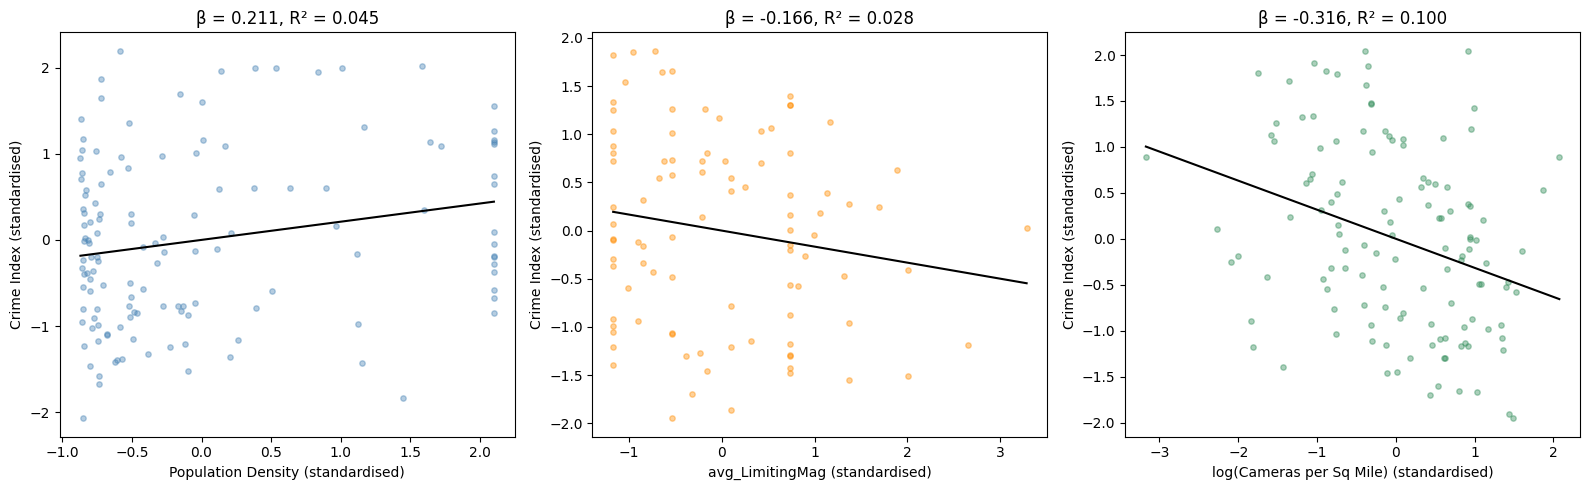

In [52]:
#prompt: generate code to perform linear regression on standardised population density, avg_LimitingMag, and log CCTV density against standardised crime index for dataset_A, dataset_B, and dataset_C, and plot scatter plots with fitted regression lines showing the beta value and R².
# Fit simple linear regression models for each standardised dataset
reg_A = stats.linregress(dataset_A_std['population_density'], dataset_A_std['Crime Index'])
reg_B = stats.linregress(dataset_B_std['avg_LimitingMag'],         dataset_B_std['Crime Index'])
reg_C = stats.linregress(dataset_C_std['log_cameras_per_sq_mile'], dataset_C_std['Crime Index'])

# Create 3 side-by-side plots and store plotting settings for each dataset
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
configs = [
    (dataset_A_std, 'population_density', reg_A, 'steelblue',  'Population Density (standardised)'),
    (dataset_B_std, 'avg_LimitingMag',         reg_B, 'darkorange', 'avg_LimitingMag (standardised)'),
    (dataset_C_std, 'log_cameras_per_sq_mile',  reg_C, 'seagreen',  'log(Cameras per Sq Mile) (standardised)'),
]

# Plot scatter points and fitted regression line for each predictor against Crime Index
for ax, (ds, col, reg, colour, xlabel) in zip(axes, configs):
    ax.scatter(ds[col], ds['Crime Index'], alpha=0.4, s=15, color=colour)
    x_range = [ds[col].min(), ds[col].max()]
    ax.plot(x_range, [reg.intercept + reg.slope * x for x in x_range], color='black', linewidth=1.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Crime Index (standardised)')
    ax.set_title(f'β = {reg.slope:.3f}, R² = {reg.rvalue**2:.3f}')

# Adjust layout and display the regression comparison plots
plt.tight_layout()
plt.show()

**Interpretation:** However, since the linear model for population density shows low R², linear regression is likely to not be the best model for the data. Hence, we test whether a quadratic (degree-2) polynomial captures a better fit (see below). A non-linear relationship might exist if both very low and very high density areas have high crime.

**Limitations.** The true relationship between variables is likely to be non-linear given the low R², so different models should be explored to see if a better fit can be found.

### Polynomial regression for Population Density


**Goal:** The goal is to model the relationship between population density and crime index more accurately as opposed to a linear regression model.
Since the linear model for population density shows low R², we test whether a quadratic (degree-2) polynomial captures a better fit. A non-linear relationship might exist if both very low and very high density areas have high crime.

**Methods / measures:** We fit a polynomial regression model for population density against crime index using the standardised datasets. This will allow us to compare the value of R² with that of the linear regression model.

**Code:** The code performs polynomial regression for the population density dataset and crime index dataset, then compares the plots and R² values for the linear and polynomial regression models.

Required info | Your answer
-------------------|------------------
GenAI tool name | Claude AI
Input prompt | generate code to fit and compare a linear regression and a degree-2 polynomial regression between standardised population density and standardised crime index in dataset_A, print the R² values and linear p-value and plot both models side by side.
Generated output |see comments under Data analysis(Visualization) - code cell 7


Linear    R² = 0.0447, p = 0.0146
Polynomial R² = 0.0474


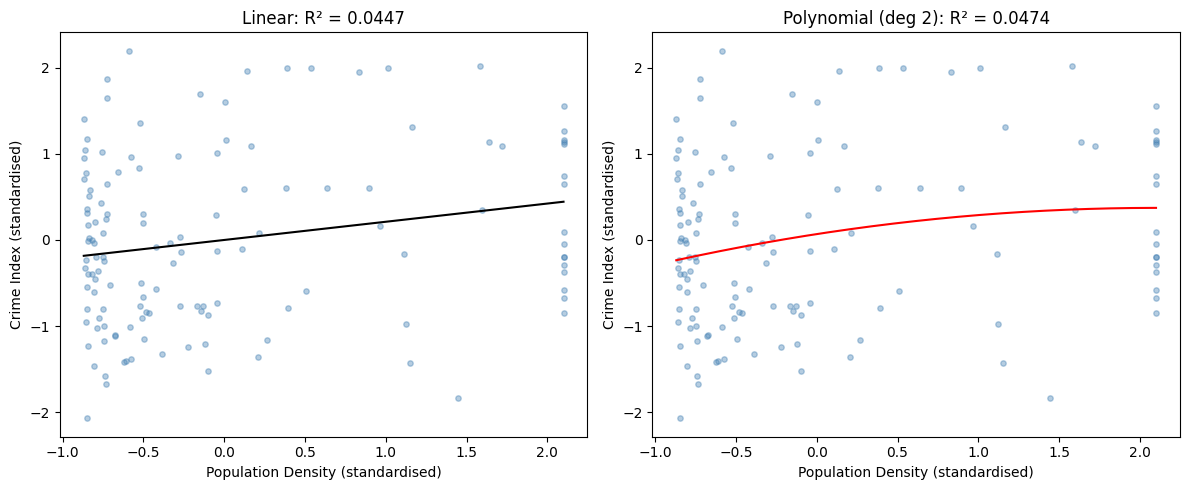

In [53]:
#prompt:  generate code to fit and compare a linear regression and a degree-2 polynomial regression between standardised population density and standardised crime index in dataset_A, print the R² values and linear p-value and plot both models side by side.
# Polynomial regression (degree 2) for Dataset A
x = dataset_A_std['population_density'].values
y = dataset_A_std['Crime Index'].values

coeffs = np.polyfit(x, y, 2)
poly = np.poly1d(coeffs)

# R² for polynomial
y_pred_poly = poly(x)
ss_res = np.sum((y - y_pred_poly) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2_poly = 1 - ss_res / ss_tot

print(f'Linear    R² = {reg_A.rvalue**2:.4f}, p = {reg_A.pvalue:.4f}')
print(f'Polynomial R² = {r2_poly:.4f}')

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Linear
axes[0].scatter(x, y, alpha=0.4, s=15, color='steelblue')
x_range = np.linspace(x.min(), x.max(), 200)
axes[0].plot(x_range, reg_A.intercept + reg_A.slope * x_range, color='black', linewidth=1.5)
axes[0].set_title(f'Linear: R² = {reg_A.rvalue**2:.4f}')
axes[0].set_xlabel('Population Density (standardised)')
axes[0].set_ylabel('Crime Index (standardised)')

# Polynomial
axes[1].scatter(x, y, alpha=0.4, s=15, color='steelblue')
axes[1].plot(x_range, poly(x_range), color='red', linewidth=1.5)
axes[1].set_title(f'Polynomial (deg 2): R² = {r2_poly:.4f}')
axes[1].set_xlabel('Population Density (standardised)')
axes[1].set_ylabel('Crime Index (standardised)')

plt.tight_layout()
plt.show()

In [54]:
results = pd.DataFrame({
    'Factor':               ['Population Density', 'Night Brightness (LimitingMag)', 'CCTV Density'],
    'Beta Coefficient':     [reg_A.slope,          reg_B.slope,                      reg_C.slope],
    'R²':                  [reg_A.rvalue**2,       reg_B.rvalue**2,                  reg_C.rvalue**2],
    'p-value':              [reg_A.pvalue,          reg_B.pvalue,                     reg_C.pvalue],
    'Significant (p<0.05)': [reg_A.pvalue < 0.05,  reg_B.pvalue < 0.05,              reg_C.pvalue < 0.05],
    'N':                    [len(dataset_A),        len(dataset_B),                   len(dataset_C)]
})

pd.set_option('display.float_format', '{:.4f}'.format)
print(results.to_string(index=False))

                        Factor  Beta Coefficient     R²  p-value  Significant (p<0.05)   N
            Population Density            0.2113 0.0447   0.0146                  True 133
Night Brightness (LimitingMag)           -0.1662 0.0276   0.1094                 False  94
                  CCTV Density           -0.3164 0.1001   0.0003                  True 124


**Interpretation:**
After performing polynomial regression on population density, we observe an increase in the R^2 value.

The table above summarises the standardised beta coefficient, R², and p-value for each model, allowing direct comparison of the strength of each factor's association with crime index. The brightness dataset has a p-value of 0.1094 (> 0.05), so it is not statistically significant. The CCTV density dataset has a p-value of 0.0003 (< 0.05), so it is statistically significant. The population density dataset has a p-value of 0.0146 (< 0.05), so it is statistically significant.
> **Note on LimitingMag direction:** LimitingMag is an inverted brightness scale — a higher value means a *darker* sky (less light pollution). A negative β means brighter/more light-polluted cities tend to have higher crime.

**Limitations**: While population density and CCTV density show statistically significant associations with crime index, no single urban development factor alone is a reliable predictor of crime due to the low R^2 values. This means the models have limited predictive utility. Crime is a complex outcome shaped by many unmeasured factors such as socioeconomic inequality, policing strategies, cultural norms, and governance quality, which are not captured by our three urban development factors alone. The regression results should therefore be interpreted as evidence of statistical association rather than as reliable tools for predicting crime in a new city.

### Refining Linear Regression for CCTV Dataset




**Goal:** The goal is to check if the results obtained from the linear regression analysis done on the CCTV dataset is a general finding, since the dataset is dominated by Chinese cities which have very high CCTV counts but relatively low crime indices.

**Methods / measures:** To test whether the significant CCTV result is driven by this geographic confound, we repeat the regression after excluding Chinese cities.

**Code:** The code excludes Chinese cities from the dataset, then standardises it and performs regression analysis.

Required info | Your answer
-------------------|------------------
GenAI tool name | Claude AI
Input prompt | generate code to remove Chinese cities from dataset_C, standardise log CCTV density and crime index, run linear regression with and without China, compare beta, R² and p-values and print whether the result remains significant.
Generated output |see comments under Data analysis(Visualization) - code cell 8


In [55]:
#prompt: generate code to remove Chinese cities from dataset_C, standardise log CCTV density and crime index, run linear regression with and without China, compare beta, R² and p-values and print whether the result remains significant.
# Exclude Chinese cities from Dataset C
dataset_C_no_china = dataset_C[dataset_C['country'].str.lower() != 'china'].reset_index(drop=True)
print(f'Dataset C full:       {len(dataset_C)} cities')
print(f'Dataset C (no China): {len(dataset_C_no_china)} cities')
print(f'Chinese cities removed: {len(dataset_C) - len(dataset_C_no_china)}')

# Standardise
dataset_C_no_china_std = dataset_C_no_china.copy()
dataset_C_no_china_std['log_cameras_per_sq_mile'] = z_score(dataset_C_no_china['log_cameras_per_sq_mile'])
dataset_C_no_china_std['Crime Index']             = z_score(dataset_C_no_china['Crime Index'])

# Regression without China
reg_C_no_china = stats.linregress(
    dataset_C_no_china_std['log_cameras_per_sq_mile'],
    dataset_C_no_china_std['Crime Index']
)

print(f'\nWith China:    β = {reg_C.slope:.4f}, R² = {reg_C.rvalue**2:.4f}, p = {reg_C.pvalue:.4f}')
print(f'Without China: β = {reg_C_no_china.slope:.4f}, R² = {reg_C_no_china.rvalue**2:.4f}, p = {reg_C_no_china.pvalue:.4f}')

if reg_C_no_china.pvalue < 0.05:
    print('\nResult remains significant without China — finding is generalisable.')
else:
    print('\nResult loses significance without China — finding is likely driven by the geographic confound.')

Dataset C full:       124 cities
Dataset C (no China): 92 cities
Chinese cities removed: 32

With China:    β = -0.3164, R² = 0.1001, p = 0.0003
Without China: β = -0.0634, R² = 0.0040, p = 0.5480

Result loses significance without China — finding is likely driven by the geographic confound.


We then plot the linear relationships of both models, allowing us to visually see the difference in results when Chinese cities are excluded.

Required info | Your answer
-------------------|------------------
GenAI tool name | Claude AI
Input prompt | generate code to rcreate two side-by-side scatter plots comparing the standardised CCTV–crime relationship for all cities versus excluding China, highlight Chinese cities in red in the full dataset, add regression lines with beta and p-values and include sample sizes in the titles.
Generated output |see comments under Data analysis(Visualization) - code cell 9


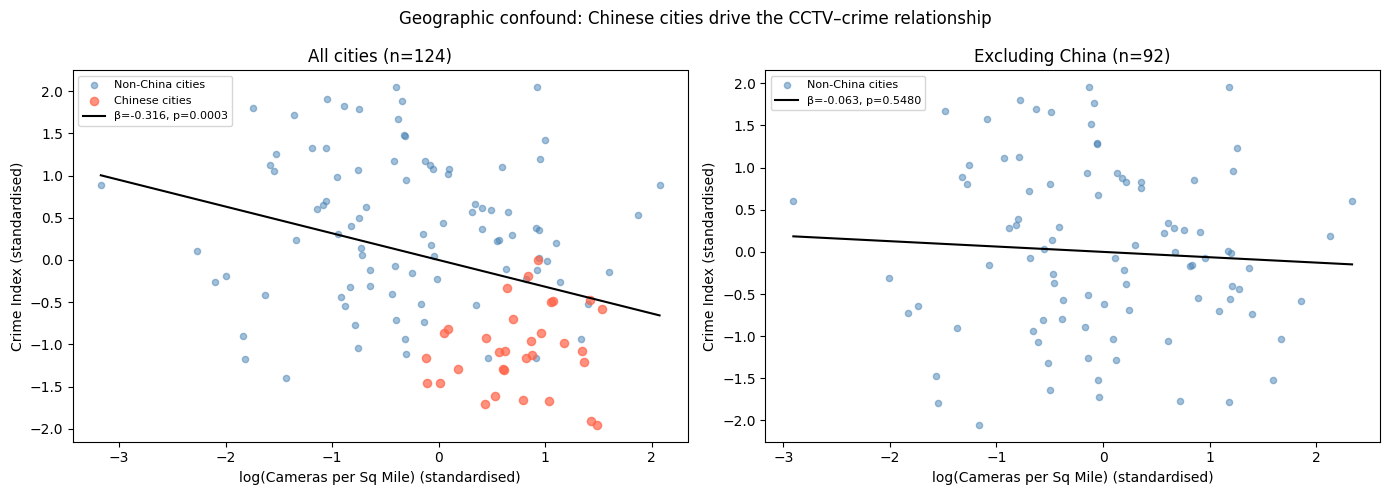

In [56]:
#prompt: generate code to rcreate two side-by-side scatter plots comparing the standardised CCTV–crime relationship for all cities versus excluding China, highlight Chinese cities in red in the full dataset, add regression lines with beta and p-values and include sample sizes in the titles.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Identify Chinese cities within the standardised dataset
is_china = dataset_C_std['country'].str.lower() == 'china'
x_all = dataset_C_std['log_cameras_per_sq_mile']
y_all = dataset_C_std['Crime Index']
x_no  = dataset_C_no_china_std['log_cameras_per_sq_mile']
y_no  = dataset_C_no_china_std['Crime Index']

# Left: full dataset — China highlighted in red
axes[0].scatter(x_all[~is_china], y_all[~is_china], alpha=0.5, s=20, color='steelblue', label='Non-China cities')
axes[0].scatter(x_all[is_china],  y_all[is_china],  alpha=0.7, s=35, color='tomato',    label='Chinese cities')
x_range = [x_all.min(), x_all.max()]
axes[0].plot(x_range, [reg_C.intercept + reg_C.slope * x for x in x_range],
             color='black', linewidth=1.5, label=f'β={reg_C.slope:.3f}, p={reg_C.pvalue:.4f}')
axes[0].set_xlabel('log(Cameras per Sq Mile) (standardised)')
axes[0].set_ylabel('Crime Index (standardised)')
axes[0].set_title(f'All cities (n={len(dataset_C_std)})')
axes[0].legend(fontsize=8)

# Right: without China — relationship disappears
axes[1].scatter(x_no, y_no, alpha=0.5, s=20, color='steelblue', label='Non-China cities')
x_range_no = [x_no.min(), x_no.max()]
axes[1].plot(x_range_no, [reg_C_no_china.intercept + reg_C_no_china.slope * x for x in x_range_no],
             color='black', linewidth=1.5, label=f'β={reg_C_no_china.slope:.3f}, p={reg_C_no_china.pvalue:.4f}')
axes[1].set_xlabel('log(Cameras per Sq Mile) (standardised)')
axes[1].set_ylabel('Crime Index (standardised)')
axes[1].set_title(f'Excluding China (n={len(dataset_C_no_china_std)})')
axes[1].legend(fontsize=8)

plt.suptitle('Geographic confound: Chinese cities drive the CCTV–crime relationship', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation.** The result loses statistical significance without the inclusion of Chinese cities as its p-value changes largely to 0.5480 (> 0.05), so the previous statistically significant result was likely to be driven by the geographic bias.

This means the CCTV finding cannot be generalised globally — it reflects a pattern specific to Chinese cities and should not be used to conclude that increased surveillance reduces crime in other regions.

**Limitations.** Removing Chinese cities addresses one source of geographic confounding but does not eliminate other unobserved differences between cities that may influence the results of the regression analysis that we obtained.

# Presentation of main results (Share)



## Stakeholders

The findings of this analysis are relevant to the following stakeholders:

- **Urban planners and city governments:** Findings on population density suggest that urban densification strategies should be paired with investment in social infrastructure (e.g. community services, public spaces) to mitigate potential increases in crime.
- **Public safety officials and law enforcement:** The CCTV confound finding is directly relevant. It cautions against over-attributing crime reduction to surveillance technology without accounting for broader cultural and governance differences across regions.
- **Policy makers and criminologists:** The low R² values across all models highlight that crime cannot be effectively addressed through urban structural changes alone. Policies targeting socioeconomic inequality, education, and community cohesion are likely to have greater impact.


## Visualization

Required info | Your answer
-------------------|------------------
GenAI tool name | Claude AI
Input prompt | generate code to create a horizontal bar chart comparing the standardised beta coefficients of population density, night brightness and CCTV density on crime index, colour bars by statistical significance, label each factor’s p-value and add a legend.
Generated output |see comments under Data analysis(Visualization) - code cell 10


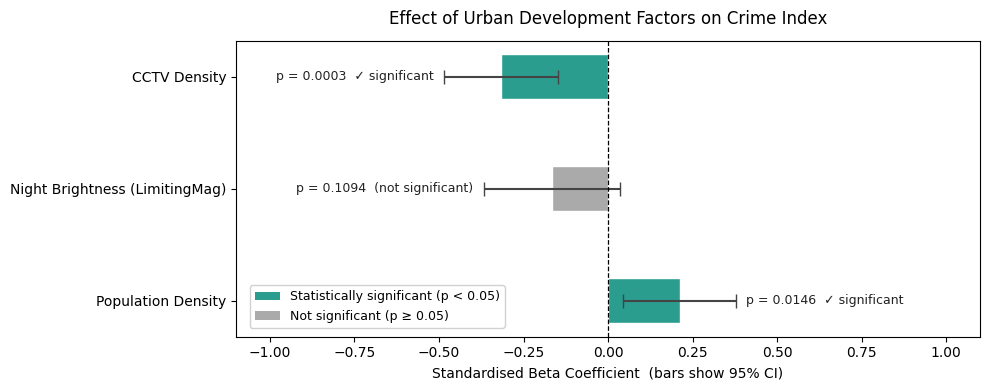

In [57]:
#prompt: generate code to create a horizontal bar chart comparing the standardised beta coefficients of population density, night brightness and CCTV density on crime index, colour bars by statistical significance, label each factor’s p-value and add a legend.

# Panel 1: Beta coefficient comparison across all three factors
fig, ax = plt.subplots(figsize=(10, 4))

factors = ['Population Density', 'Night Brightness (LimitingMag)', 'CCTV Density']
betas   = [reg_A.slope,  reg_B.slope,  reg_C.slope]
errors  = [reg_A.stderr * 1.96, reg_B.stderr * 1.96, reg_C.stderr * 1.96]
pvals   = [reg_A.pvalue, reg_B.pvalue, reg_C.pvalue]
colors  = ['#2a9d8f' if p < 0.05 else '#aaaaaa' for p in pvals]

ax.barh(factors, betas, xerr=errors, color=colors, height=0.4,
        capsize=5, error_kw={'elinewidth': 1.5, 'ecolor': '#444'}, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.9, linestyle='--')

# Labels placed clearly outside each bar, away from the centre line
for i, (beta, p, err) in enumerate(zip(betas, pvals, errors)):
    label = 'p = {:.4f}  ✓ significant'.format(p) if p < 0.05 else 'p = {:.4f}  (not significant)'.format(p)
    if beta >= 0:
        ax.text(beta + err + 0.03, i, label, va='center', ha='left', fontsize=9, color='#222')
    else:
        ax.text(beta - err - 0.03, i, label, va='center', ha='right', fontsize=9, color='#222')

ax.set_xlabel('Standardised Beta Coefficient  (bars show 95% CI)', fontsize=10)
ax.set_title('Effect of Urban Development Factors on Crime Index', fontsize=12, pad=12)
ax.set_xlim(-1.1, 1.1)

legend_elements = [Patch(facecolor='#2a9d8f', label='Statistically significant (p < 0.05)'),
                   Patch(facecolor='#aaaaaa', label='Not significant (p ≥ 0.05)')]
ax.legend(handles=legend_elements, fontsize=9, loc='lower left',
          bbox_to_anchor=(0.01, 0.01), framealpha=0.9)

plt.tight_layout()
plt.show()

Required info | Your answer
-------------------|------------------
GenAI tool name | Claude AI
Input prompt | generate code to create a bar chart comparing the standardised beta coefficients of CCTV density on crime index for the full dataset versus excluding China, colour the bars differently, label each bar’s p-value and significance and add a title and axis labels.
Generated output |see comments under Data analysis(Visualization) - code cell 10


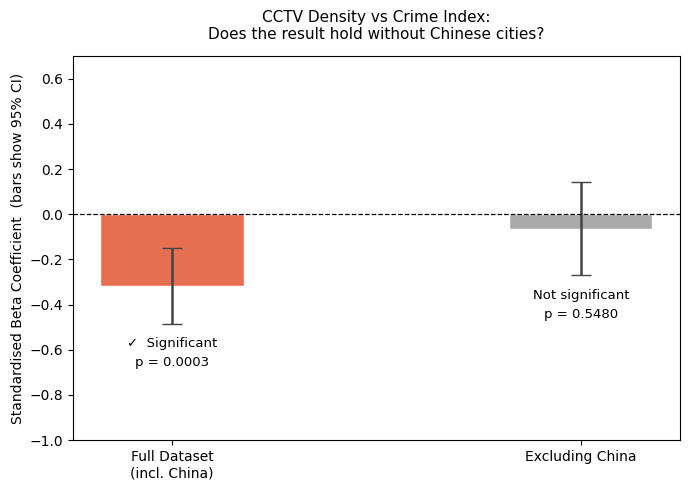

In [58]:
#prompt: generate code to create a bar chart comparing the standardised beta coefficients of CCTV density on crime index for the full dataset versus excluding China, colour the bars differently, label each bar’s p-value and significance and add a title and axis labels.
# Panel 2: CCTV geographic confound — with vs without China
fig, ax = plt.subplots(figsize=(7, 5))

labels_c = ['Full Dataset\n(incl. China)', 'Excluding China']
betas_c  = [reg_C.slope, reg_C_no_china.slope]
errors_c = [reg_C.stderr * 1.96, reg_C_no_china.stderr * 1.96]
pvals_c  = [reg_C.pvalue, reg_C_no_china.pvalue]
colors_c = ['#e76f51', '#aaaaaa']

ax.bar(labels_c, betas_c, yerr=errors_c, color=colors_c, edgecolor='white',
       width=0.35, capsize=7, error_kw={'elinewidth': 1.8, 'ecolor': '#444'})
ax.axhline(0, color='black', linewidth=0.9, linestyle='--')

# Labels placed strictly outside each bar (below for negative β, above for positive)
for i, (beta, p, err) in enumerate(zip(betas_c, pvals_c, errors_c)):
    if p < 0.05:
        sig_line1 = '✓  Significant'
        sig_line2 = 'p = {:.4f}'.format(p)
    else:
        sig_line1 = 'Not significant'
        sig_line2 = 'p = {:.4f}'.format(p)

    if beta < 0:
        # annotation below the bottom error bar tip
        y_text = beta - err - 0.06
        ax.text(i, y_text, sig_line1 + '\n' + sig_line2,
                ha='center', va='top', fontsize=9.5, linespacing=1.6)
    else:
        # annotation above the top error bar tip
        y_text = beta + err + 0.06
        ax.text(i, y_text, sig_line1 + '\n' + sig_line2,
                ha='center', va='bottom', fontsize=9.5, linespacing=1.6)

ax.set_ylabel('Standardised Beta Coefficient  (bars show 95% CI)', fontsize=10)
ax.set_title('CCTV Density vs Crime Index:\nDoes the result hold without Chinese cities?', fontsize=11, pad=12)
ax.set_ylim(-1.0, 0.7)

plt.tight_layout()
plt.show()

**Narrative** Our analysis investigated three urban developmental factors — population density, night brightness (LimitingMag), and CCTV density — and their association with city-level crime index. The key findings are as follows:

- **Population Density** shows a statistically significant positive association with crime index (p = 0.0146). Denser cities tend to have higher crime, though the effect size is modest and the model explains only a small proportion of variance (low R²).
- **Night Brightness (LimitingMag)** does not show a statistically significant association with crime index (p = 0.1094). We cannot conclude from our data that lighting intensity is a meaningful predictor of crime at the city level.
- **CCTV Density** initially shows a statistically significant negative association (p = 0.0003), suggesting cities with more cameras have lower crime. However, this finding does not hold once Chinese cities are excluded (p = 0.5480), revealing it to be a **geographic confound** driven by China's unique combination of very high CCTV coverage and low reported crime index, rather than a general global pattern.

Of the three urban development factors studied, only population density shows a statistically significant and generalisable association with crime rate. Night brightness and CCTV density do not demonstrate robust associations. The consistently low R² values (≤ 10%) across all models suggest that urban development factors alone are insufficient predictors of crime and the relationship is likely driven by broader social, economic, and governance factors.

# Possible actions based on results (Act)

Based on our findings, we propose the following actions for relevant stakeholders:

1. **Accompany densification with social investment.** Since higher population density is associated with higher crime, urban development projects that increase city density should be complemented by investment in community infrastructure, public services, and social cohesion programmes rather than assuming density alone will lead to positive outcomes.

2. **Exercise caution in CCTV expansion policies.** The significant CCTV-crime association disappears when Chinese cities are excluded, suggesting the relationship is not globally generalisable. Policy makers should not rely on cross-country observational data alone to justify large-scale surveillance infrastructure. Localised, controlled studies would be needed to establish causal effects.

3. **Prioritise multi-factor approaches to crime reduction.** Our results indicate that no single urban developmental factor strongly predicts crime. Effective crime reduction strategies should address multiple dimensions such as economic inequality, education access, and community policing rather than focusing on any one structural factor.


# Final Reflection



## Considerations on data ethics


Several ethical considerations arise from this analysis:

- **Risk of stigmatisation:** Associating city names with high crime indices carries the risk of stigmatising certain cities or regions, particularly those in developing countries. Causal claims must not be drawn from these results, and findings should not be used to justify discriminatory policies.

- **CCTV and mass surveillance:** The use of CCTV camera density data in this analysis touches directly on the topic of mass surveillance. Our findings could be misused to advocate for increased surveillance. We stress that our analysis does not establish a causal link between CCTV deployment and crime reduction, and any policy application should involve independent ethical review.


## Considerations on data privacy and security

Using aggregate-level city data, individual privacy is better protected as compared to using more granular data on neighbourhoods and specific locations, where individuals could potentially be identified from crime data.